# Многокритериальные методы поддержки принятия решений

## Ноутбук-спутник: разобранные примеры к каждому методу

**Курс:** 4. Математические и инструментальные методы поддержки принятия решений
**Модуль:** «Агент, принимающий решения» · **Пара к ноутбуку:** `MCDA_Agent_Policy_Unity_v4.ipynb`

---

### Зачем нужен этот ноутбук

Модуль состоит из двух ноутбуков.

| Ноутбук | Что в нём |
|---|---|
| **Основной** — `MCDA_Agent_Policy_Unity_v4.ipynb` | одна задача от начала до конца: путешественник выбирает, как дойти до горного приюта. Теория каждого метода, формулы, код, политика для Unity, мини-симулятор |
| **Спутник** — этот ноутбук | небольшие житейские задачи (квартира, смартфон, база практики, поставщик, зарплата, кофейня, зал для конференции, курс повышения квалификации), решённые вручную шаг за шагом и проверенные кодом |

Примеры **не связаны** с задачей путешественника. Их цель — показать, как работает метод,
на числах, которые легко проверить на калькуляторе. Сначала прочитайте теорию метода
в основном ноутбуке, затем разберите пример здесь, затем вернитесь к основной задаче.

**Нумерация совпадает:** пример 3.1 относится к §3 основного ноутбука, формула (5.4) —
та же формула (5.4), что в основном ноутбуке.

### Как устроен каждый раздел

1. **Пример с ручным решением** — условие, шаги, ответ и разбор.
2. **Ячейка с кодом**, которая решает тот же пример функциями из основного ноутбука
   и сверяет результат с ручным расчётом. Строка «совпадает с ручным расчётом» означает,
   что код и вычисления на бумаге дали одно и то же.

Функции методов (нормализация, SAW, WPM, AHP, TOPSIS, MAUT, VIKOR, ELECTRE, Спирмен)
скопированы из основного ноутбука в одну ячейку в начале. Поэтому этот ноутбук
**самостоятельный**: его можно запускать, не открывая основной.

### Оглавление

| § | Примеры |
|---|---|
| 0 | сквозной пример: пять квартир |
| 2 | 2.1 — нормализация столбцов; 2.2 — множество Парето квартир |
| 3 | 3.1 — смартфоны методом SAW; 3.2 — те же смартфоны методом WPM; мини-пример «перекос против ровности» |
| 4 | 4.1 — база для учебной практики (AHP полностью); 4.2 — несогласованные суждения |
| 5 | 5.1 — поставщик оргтехники (TOPSIS) |
| 6 | 6.1 — гарантированная зарплата или бонус; 6.2 — выбор предложения о работе (MAUT) |
| 7 | 7.1 — место для кофейни (VIKOR) |
| 8 | 8.1 — зал для конференции (ELECTRE I) |
| 9 | 9.1 — согласие SAW и WPM (коэффициент Спирмена) |
| 10 | 10.1 — курс повышения квалификации (критический вес) |

### Как запускать

Так же, как основной ноутбук: в VS Code выберите ядро `.venv` и нажмите **Run All**
(или в Google Colab: **Среда выполнения → Выполнить все**). Нужны только numpy, pandas
и matplotlib; если их нет, первая ячейка с кодом установит их сама. Время выполнения —
несколько секунд.

> **О записи чисел.** В тексте дробная часть отделяется запятой: $0{,}25$. В коде и
> в выводе — точкой: `0.25`. Это одно и то же число.

In [1]:
# =============================================================================
# НАСТРОЙКА ОКРУЖЕНИЯ
# -----------------------------------------------------------------------------
# Эту ячейку нужно выполнить ПЕРВОЙ: она подключает библиотеки.
# Всё, что стоит после знака #, — комментарий: Python его не выполняет.
# =============================================================================

# --- Проверка, что нужные библиотеки установлены ------------------------------
# importlib.util.find_spec ищет библиотеку, не подключая её. Если чего-то нет,
# ставим через pip именно в тот Python, на котором работает ядро ноутбука.
import sys
import importlib.util
import subprocess

_REQUIRED = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib"}
_missing = [pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Устанавливаю:", ", ".join(_missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *_missing])

# --- Подключаем библиотеки -----------------------------------------------------
# «import X as Y» — подключить библиотеку X и дальше называть её коротко Y.
import numpy as np                 # массивы чисел и математика над ними
import pandas as pd                # таблицы с подписанными строками и столбцами
import matplotlib.pyplot as plt    # графики
from typing import Dict, List, Tuple   # подсказки типов: словарь, список, кортеж
from IPython.display import display    # красивый вывод таблицы из середины ячейки

# Показывать графики прямо под ячейкой.
%matplotlib inline

# Таблицы pandas печатаем с 4 знаками после точки.
pd.set_option("display.precision", 4)


def check(name: str, got: float, expected: float, tol: float = 5e-4) -> None:
    """Сверить число, посчитанное кодом, с числом из ручного расчёта.

    np.isclose(a, b, atol=tol) — True, если |a − b| ≤ tol. Допуск нужен,
    потому что в ручном расчёте числа округлены до 3–4 знаков.
    """
    ok = np.isclose(got, expected, atol=tol)
    mark = "совпадает с ручным расчётом" if ok else "РАСХОДИТСЯ с ручным расчётом"
    # :.4f — вывести число с 4 знаками после точки.
    print(f"  {name:28s} код: {got:.4f}   вручную: {expected:.4f}   → {mark}")


print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


In [2]:
# =============================================================================
# БИБЛИОТЕКА МЕТОДОВ
# -----------------------------------------------------------------------------
# Функции скопированы из основного ноутбука без изменений по существу.
# Единственное отличие: здесь нет «основной задачи», поэтому направления
# критериев (directions) нужно передавать в каждую функцию явно —
# словарём {имя критерия: "max" или "min"}.
#   "max" — критерий-выгода: чем больше, тем лучше (площадь, качество);
#   "min" — критерий-издержка: чем меньше, тем лучше (цена, время в дороге).
# =============================================================================

# Индекс случайной согласованности RI по Саати (формула 4.4).
RI_TABLE = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
            6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}


def normalize(X: pd.DataFrame, method: str = "minmax",
              directions: Dict[str, str] = None) -> pd.DataFrame:
    """Нормализованная матрица R: все столбцы в [0, 1], «больше — лучше».

    X          — матрица решений (строки — альтернативы, столбцы — критерии);
    method     — "minmax" (2.1), "linear" (2.2) или "vector" (2.3);
    directions — словарь {критерий: "max" | "min"}: направление каждого
                 критерия. В учебных примерах его передают обязательно.
    """
    # None в Python означает «ничего, значение не задано».
    # «is None» — проверка, что аргумент не передали.
    if directions is None:
        # raise — «выбросить ошибку» с понятным сообщением.
        raise ValueError("Передайте directions: словарь {критерий: 'max' или 'min'}")

    # Пустая таблица той же формы, что X: те же подписи строк (index) и
    # столбцов (columns); dtype=float — внутри будут дробные числа.
    R = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)

    # ЦИКЛ for: переменная c по очереди принимает каждое имя столбца.
    for c in X.columns:
        # X[c] — столбец c; .astype(float) — перевести в дробные числа;
        # .values — взять «голый» массив NumPy без подписей.
        x = X[c].astype(float).values
        # Можно присвоить две переменные сразу: hi получит максимум,
        # lo — минимум столбца (x_j^max и x_j^min в формулах).
        hi, lo = x.max(), x.min()
        # == — проверка на равенство (не путать с присваиванием =).
        # benefit будет True для «выгоды» и False для «издержки».
        benefit = directions[c] == "max"

        if method == "minmax":
            # (2.1): худшее значение -> 0, лучшее -> 1.
            rng = hi - lo                          # размах столбца
            if rng < 1e-12:                        # 1e-12 = 0.000000000001
                # Все альтернативы равны по критерию: он ничего не различает.
                # Ставим всем 0.5, чтобы не делить на ноль.
                # np.full_like(x, 0.5) — массив той же длины, что x, из 0.5.
                r = np.full_like(x, 0.5)
            elif benefit:                          # elif = «иначе, если»
                r = (x - lo) / rng                 # выгода: (x - min)/(max - min)
            else:                                  # else = «во всех прочих случаях»
                r = (hi - x) / rng                 # издержка: (max - x)/(max - min)
            # Обратите внимание: x - lo вычитает число из КАЖДОГО элемента
            # массива сразу, без цикла. Так работают массивы NumPy.

        elif method == "linear":
            # (2.2): доля от лучшего значения; худшее НЕ обязательно 0.
            if benefit:
                # «A if условие else B» — однострочное условие:
                # если hi > 0, берём x / hi, иначе массив из 0.5.
                r = x / hi if hi > 1e-12 else np.full_like(x, 0.5)
            else:
                # min / x. np.where(условие, A, B) поэлементно выбирает
                # A там, где условие истинно, и B там, где ложно.
                # Нулевая издержка идеальна — её оценка 1.
                # np.maximum не даёт делить на точный ноль.
                r = np.where(x > 1e-12, lo / np.maximum(x, 1e-12), 1.0)

        elif method == "vector":
            # (2.3): делим на евклидову длину столбца sqrt(Σ x_i^2).
            nrm = np.sqrt((x ** 2).sum())
            v = x / nrm if nrm > 1e-12 else np.full_like(x, 0.5)
            # Для издержки «отражаем»: 1 - v. Отражение сохраняет расстояния
            # между альтернативами, поэтому TOPSIS даёт тот же ответ, что и
            # в классическом варианте (см. §5).
            r = v if benefit else 1.0 - v

        else:
            # raise — «выбросить ошибку»: программа остановится с сообщением.
            # Так мы защищаемся от опечатки в названии метода.
            raise ValueError(f"Неизвестный метод нормализации: {method}")

        # np.clip(r, 0, 1) обрезает значения до отрезка [0, 1] — страховка
        # от погрешностей округления. Результат записываем в столбец c.
        R[c] = np.clip(r, 0.0, 1.0)
    return R


def dominates(u: np.ndarray, v: np.ndarray) -> bool:
    """True, если строка u доминирует строку v (обе нормализованы).

    u >= v сравнивает массивы поэлементно и даёт массив из True/False.
    np.all(...) — True, если ВСЕ элементы True: «не хуже по всем критериям».
    np.any(...) — True, если ХОТЯ БЫ ОДИН True: «строго лучше хотя бы по одному».
    and — логическое «и»: нужны оба условия.
    Допуск 1e-12 защищает от ошибок округления: 0.30000000000000004 и 0.3
    для нас одно и то же число.
    """
    return bool(np.all(u >= v - 1e-12) and np.any(u > v + 1e-12))


def pareto_front(X: pd.DataFrame, directions: Dict[str, str] = None) -> List[str]:
    """Имена Парето-оптимальных альтернатив — тех, кого никто не доминирует."""
    R = normalize(X, "minmax", directions).values   # массив формы (n, m)
    names = list(X.index)                  # list(...) — превратить в список
    front = []                             # пустой список: сюда будем добавлять
    # enumerate(names) выдаёт пары (номер, имя): (0, "DIRECT"), (1, "SHELTERED")...
    for i, name in enumerate(names):
        # R[i] — i-я строка массива. range(len(names)) — числа 0, 1, ..., n-1.
        # any(... for j in ...) — True, если нашлась хотя бы одна
        # альтернатива j (не сама i), которая доминирует i.
        dominated = any(dominates(R[j], R[i])
                        for j in range(len(names)) if j != i)   # != — «не равно»
        if not dominated:
            front.append(name)             # .append — добавить в конец списка
    return front


def dominance_matrix(X: pd.DataFrame, directions: Dict[str, str] = None) -> pd.DataFrame:
    """Таблица n × n: 1 в клетке (a, b), если a доминирует b."""
    R = normalize(X, "minmax", directions).values
    n = len(X)                             # число альтернатив
    # Таблица из нулей с подписями строк и столбцов — именами альтернатив.
    D = pd.DataFrame(0, index=X.index, columns=X.index)
    for i in range(n):          # строка — «кто доминирует»
        for j in range(n):      # столбец — «кого доминируют» (вложенный цикл)
            if i != j and dominates(R[i], R[j]):
                # .iloc[i, j] — обращение к клетке по НОМЕРАМ строки и столбца.
                D.iloc[i, j] = 1
    return D


def saw(X: pd.DataFrame, w: pd.Series, norm: str = "minmax",
        directions: Dict[str, str] = None) -> pd.Series:
    """SAW: F(a_i) = Σ_j w_j · r_ij — взвешенная сумма нормализованных оценок.

    Возвращает баллы альтернатив, отсортированные от лучшей к худшей.
    """
    R = normalize(X, norm, directions)     # шаг 1: нормализация, форма (n, m)
    # шаг 2: R * w[R.columns] умножает КАЖДЫЙ столбец на свой вес.
    # w[R.columns] выстраивает веса в том же порядке, что и столбцы R, —
    # защита от ошибки, если критерии в w перечислены в другом порядке.
    weighted = R * w[R.columns]
    # шаг 3: .sum(axis=1) — сумма ВДОЛЬ строки (по всем критериям).
    # axis=0 означало бы «по столбцу» (сверху вниз), axis=1 — «по строке».
    # .sort_values(ascending=False) — сортировка по убыванию.
    return weighted.sum(axis=1).sort_values(ascending=False)


def wpm(X: pd.DataFrame, w: pd.Series, norm: str = "linear", eps: float = 1e-6,
        directions: Dict[str, str] = None) -> pd.Series:
    """WPM: F(a_i) = Π_j r_ij^w_j — взвешенное произведение.

    Произведение многих чисел < 1 быстро становится очень маленьким, поэтому
    считаем через логарифм: ln F = Σ_j w_j · ln r_ij, затем F = exp(ln F).
    Это та же формула (3.2), только численно устойчивее.
    """
    # Нормализация по лучшему (2.2): у неё нет нулей, а ноль в произведении
    # обнулил бы всю оценку. .clip(lower=eps) — вторая страховка:
    # ln(0) = -∞, поэтому заменяем точные нули на крошечное eps.
    R = normalize(X, norm, directions).clip(lower=eps)
    # np.log — натуральный логарифм КАЖДОГО элемента таблицы.
    logs = (np.log(R) * w[R.columns]).sum(axis=1)   # Σ_j w_j · ln r_ij
    # np.exp — обратная операция: e в степени. Возвращаемся из логарифмов.
    return np.exp(logs).sort_values(ascending=False)


def ahp_weights(P: np.ndarray, labels: List[str]) -> Tuple[pd.Series, float, float, float]:
    """Веса, λ_max, CI и CR по матрице парных сравнений P (формулы 4.1–4.4).

    Функция возвращает сразу ЧЕТЫРЕ значения (кортеж). При вызове их можно
    разложить по четырём переменным: w, lam, CI, CR = ahp_weights(...).
    """
    P = np.asarray(P, dtype=float)     # превратить вход (например, список
                                       # списков) в массив NumPy
    m = P.shape[0]                     # .shape — форма массива (строк, столбцов)
    # assert проверяет условие и останавливает программу, если оно ложно.
    assert P.shape == (m, m), "Матрица парных сравнений должна быть квадратной"

    # np.linalg.eig возвращает ВСЕ собственные числа и собственные векторы.
    # У положительной обратносимметричной матрицы наибольшее собственное
    # число вещественно (теорема Перрона — Фробениуса).
    eigval, eigvec = np.linalg.eig(P)
    # .real — вещественная часть (NumPy может вернуть комплексные числа);
    # np.argmax — НОМЕР наибольшего элемента.
    k = int(np.argmax(eigval.real))
    lam_max = float(eigval[k].real)                 # λ_max из формулы (4.1)

    # eigvec[:, k] — k-й СТОЛБЕЦ массива (двоеточие = «все строки»).
    # Собственный вектор определён с точностью до множителя и знака,
    # поэтому берём модуль (np.abs) и нормируем к сумме 1.
    v = np.abs(eigvec[:, k].real)
    w = pd.Series(v / v.sum(), index=labels)

    CI = (lam_max - m) / (m - 1) if m > 1 else 0.0              # (4.4)
    # .get(m, 1.49) — взять значение по ключу m, а если его нет — 1.49.
    RI = RI_TABLE.get(m, 1.49)
    CR = CI / RI if RI > 0 else 0.0                             # (4.4)
    return w, lam_max, CI, CR


def topsis(X: pd.DataFrame, w: pd.Series, norm: str = "vector",
           detail: bool = False, directions: Dict[str, str] = None):
    """TOPSIS: C_i = d_i^- / (d_i^+ + d_i^-).

    detail=False — вернуть только коэффициенты близости C (отсортированные);
    detail=True  — вернуть таблицу с расстояниями d+, d- и C.
    """
    # Шаг 1 (5.1). Векторная нормализация. Для издержек функция normalize
    # уже выполнила отражение 1 - v, поэтому дальше ВСЕ столбцы — «выгоды».
    R = normalize(X, norm, directions)

    # Шаг 2 (5.2). Взвешивание: v_ij = w_j · r_ij. Вес «растягивает» ось
    # своего критерия: важный критерий сильнее влияет на расстояния.
    V = R * w[R.columns]

    # Шаг 3 (5.3). Идеальная и антиидеальная точки. Всё приведено к
    # «больше — лучше», поэтому идеал — максимум столбца, антиидеал — минимум.
    # axis=0: вычисляем ВДОЛЬ столбца (по всем строкам) — одно число
    # на каждый столбец. Результат — Series из 5 чисел.
    ideal      = V.max(axis=0)
    anti_ideal = V.min(axis=0)

    # Шаг 4 (5.4). Евклидовы расстояния до идеала и антиидеала:
    # корень из суммы квадратов разностей по всем критериям.
    # V - ideal вычитает строку ideal из КАЖДОЙ строки V — это называется
    # «broadcasting» (растягивание), цикл писать не нужно.
    # ** 2 — возведение в квадрат; np.sqrt — квадратный корень.
    d_plus  = np.sqrt(((V - ideal)      ** 2).sum(axis=1))
    d_minus = np.sqrt(((V - anti_ideal) ** 2).sum(axis=1))

    # Шаг 5 (5.5). Коэффициент относительной близости. 1e-12 в знаменателе
    # спасает от деления на ноль, если все альтернативы совпадают.
    C = d_minus / (d_plus + d_minus + 1e-12)

    if detail:
        # Скобки вокруг длинного выражения позволяют перенести его на
        # несколько строк — Python продолжит читать до закрывающей скобки.
        return (pd.DataFrame({"d+": d_plus, "d-": d_minus, "C": C})
                .sort_values("C", ascending=False))
    return C.sort_values(ascending=False)


def utility(x: np.ndarray, c: float) -> np.ndarray:
    """Экспоненциальная функция полезности на [0, 1] (формула 6.3).

    u(0) = 0, u(1) = 1 при любом c.
    c > 0 — вогнутая функция, неприятие риска (осторожность);
    c < 0 — выпуклая функция, склонность к риску (азарт);
    c = 0 — прямая u(x) = x: MAUT совпадает с SAW.
    """
    x = np.asarray(x, dtype=float)
    # abs(c) — модуль числа. При c, очень близком к нулю, формула дала бы
    # деление 0/0, поэтому отдельно возвращаем её предел — сам x.
    if abs(c) < 1e-9:
        return x
    # np.exp(-c * x) — e в степени (-c·x) для каждого элемента массива.
    return (1 - np.exp(-c * x)) / (1 - np.exp(-c))


def maut(X: pd.DataFrame, w: pd.Series,
         attitude: Dict[str, float] = None, norm: str = "minmax",
         directions: Dict[str, str] = None) -> pd.Series:
    """MAUT: U(a_i) = Σ_j k_j · u_j(x'_ij) — аддитивная модель полезности (6.4).

    Роль шкалирующих коэффициентов k_j здесь играют веса w.
    """
    # x' — значение, приведённое к [0, 1] и направлению «больше — лучше».
    # В коде шкала берётся min–max по текущей матрице; в учебном примере
    # ЛПР задавал диапазоны сам (см. текст) — это единственное отличие.
    R = normalize(X, norm, directions)
    attitude = attitude or {}          # «or {}»: если словарь не передан — пустой
    # Для каждого критерия c применяем свою функцию полезности со своим c_j.
    # attitude.get(c, 0.0): если коэффициент не задан, считаем критерий
    # нейтральным к риску (линейная полезность).
    # R[c].values — массив значений столбца c.
    U = pd.DataFrame({c: utility(R[c].values, attitude.get(c, 0.0))
                      for c in R.columns}, index=R.index)
    # Аддитивная свёртка — та же взвешенная сумма, что в SAW,
    # только от полезностей u_j(x'), а не от самих x'.
    return (U * w[U.columns]).sum(axis=1).sort_values(ascending=False)


def vikor(X: pd.DataFrame, w: pd.Series, nu: float = 0.5,
          directions: Dict[str, str] = None) -> Tuple[pd.DataFrame, List[str]]:
    """VIKOR: таблица S, R, Q (меньше — лучше) и компромиссное множество."""
    # Нормализация min–max не меняет результата VIKOR: доля недобора (7.1)
    # не зависит от линейного изменения шкалы. Зато после неё все критерии —
    # «выгоды», и лучшее значение — просто максимум.
    R = normalize(X, "minmax", directions)
    f_star, f_minus = R.max(axis=0), R.min(axis=0)       # f_j* и f_j^-
    # .replace(0, 1e-12) заменяет нулевой размах крошечным числом,
    # чтобы не делить на ноль.
    rng = (f_star - f_minus).replace(0, 1e-12)

    # (7.1) Доля недобора до лучшего значения по каждому критерию, в [0, 1].
    D = (f_star - R) / rng
    WD = D * w[R.columns]                                 # взвешенные недоборы

    S = WD.sum(axis=1)     # (7.2) групповая полезность — «сколько всего недобрали»
    Rg = WD.max(axis=1)    # (7.3) индивидуальное сожаление — «самый большой недобор»

    # (7.4) Индекс Q: смесь нормированных S и R с весом ν.
    # ν = 0.5 — консенсус, ν > 0.5 — решение большинством, ν < 0.5 — вето.
    S_s, S_m = S.min(), S.max()
    R_s, R_m = Rg.min(), Rg.max()
    # max(a, 1e-12) — защита от деления на ноль, если все S одинаковы.
    Q = (nu * (S - S_s) / max(S_m - S_s, 1e-12)
         + (1 - nu) * (Rg - R_s) / max(R_m - R_s, 1e-12))

    out = pd.DataFrame({"S": S, "R": Rg, "Q": Q}).sort_values("Q")
    order = list(out.index)          # альтернативы по возрастанию Q
    n = len(order)

    # (7.5) Условие C1 — приемлемое преимущество: лидер опережает второго
    # хотя бы на DQ = 1/(n - 1). .iloc[0] — первая строка, .iloc[1] — вторая.
    DQ = 1.0 / (n - 1) if n > 1 else 0.0
    c1 = (out["Q"].iloc[1] - out["Q"].iloc[0] >= DQ) if n > 1 else True
    # Условие C2 — приемлемая устойчивость: лидер по Q является лучшим
    # также по S или по R. .idxmin() возвращает ИМЯ строки с минимумом;
    # or — логическое «или».
    c2 = order[0] == S.idxmin() or order[0] == Rg.idxmin()

    # Итог по правилам Opricovic & Tzeng (2004):
    #   C1 и C2 выполнены        -> единственное решение a1;
    #   C1 нарушено              -> все a, у которых Q(a) - Q(a1) < DQ;
    #   нарушено только C2       -> пара {a1, a2}.
    if c1 and c2:
        compromise = [order[0]]
    elif not c1:
        compromise = [a for a in order if out.loc[a, "Q"] - out["Q"].iloc[0] < DQ]
    else:
        compromise = order[:2]       # срез [:2] — первые два элемента списка
    return out, compromise


def electre_i(X: pd.DataFrame, w: pd.Series,
              c_thr: float = 0.55, d_thr: float = 0.55,
              directions: Dict[str, str] = None):
    """ELECTRE I: матрицы согласия C и несогласия D, граф превосходства, ядро.

    c_thr — порог согласия ĉ: «за» гипотезу должно быть не меньше ĉ веса;
    d_thr — порог несогласия d̂: самый сильный проигрыш не больше d̂.
    """
    R = normalize(X, "minmax", directions)      # все критерии — «выгоды», [0, 1]
    names = list(X.index)
    # Две пустые таблицы n × n, заполненные нулями (0.0).
    C = pd.DataFrame(0.0, index=names, columns=names)
    D = pd.DataFrame(0.0, index=names, columns=names)

    # Шкала для несогласия: наибольший размах по критериям. После min–max
    # нормализации он равен 1. Запись «... or 1.0» подставит 1.0, если
    # размах вдруг окажется нулевым.
    span = float((R.max(axis=0) - R.min(axis=0)).max()) or 1.0

    for a in names:                   # проверяем гипотезу «a не хуже b»
        for b in names:
            if a == b:
                continue              # continue — перейти к следующему шагу цикла
            # R.loc[a] — строка альтернативы a. Сравнение даёт МАСКУ:
            # True там, где a не хуже b (равенство идёт в пользу a).
            better = R.loc[a] >= R.loc[b] - 1e-12
            # (8.1) Индекс согласия: берём веса по маске и складываем.
            # w[...][better.values] оставляет только веса, где маска True.
            C.loc[a, b] = float(w[R.columns][better.values].sum())
            # (8.2) Индекс несогласия: самый большой проигрыш a по тем
            # критериям, где a хуже b. ~ обращает маску (True <-> False).
            diffs = (R.loc[b] - R.loc[a])[~better.values]
            # len(diffs) — сколько таких критериев; если ни одного — 0.0.
            D.loc[a, b] = float(diffs.max() / span) if len(diffs) else 0.0

    # (8.3) a превосходит b, если согласие достаточно велико И несогласие
    # достаточно мало. Результат — ориентированный граф (матрица смежности):
    # 1 в клетке (a, b) — стрелка из a в b.
    Out = pd.DataFrame(0, index=names, columns=names)
    for a in names:
        for b in names:
            if a != b and C.loc[a, b] >= c_thr and D.loc[a, b] <= d_thr:
                Out.loc[a, b] = 1

    # Упрощённое ядро: вершины, в которые не входит ни одна стрелка, то есть
    # альтернативы, которых никто не превосходит. Out[b] — столбец b,
    # его сумма — число входящих стрелок.
    kernel = [b for b in names if Out[b].sum() == 0]
    return C, D, Out, kernel


def spearman(a: np.ndarray, b: np.ndarray) -> float:
    """Коэффициент ранговой корреляции Спирмена.

    Считаем как корреляцию Пирсона между РАНГАМИ: это общая формула, которая
    корректно работает и при совпадающих рангах. Без совпадений она даёт
    ровно то же, что формула (9.1) с суммой квадратов разностей рангов.
    """
    ra = pd.Series(a).rank().values          # ранги первой ранжировки
    rb = pd.Series(b).rank().values          # ранги второй
    ra, rb = ra - ra.mean(), rb - rb.mean()  # центрирование: вычитаем среднее
    den = np.sqrt((ra ** 2).sum() * (rb ** 2).sum())   # знаменатель
    # np.nan — «не число»: корреляция не определена, если все ранги равны.
    return float((ra * rb).sum() / den) if den > 1e-12 else np.nan


print("Функции загружены: normalize, pareto_front, dominance_matrix, saw, wpm,")
print("ahp_weights, topsis, utility, maut, vikor, electre_i, spearman")

Функции загружены: normalize, pareto_front, dominance_matrix, saw, wpm,
ahp_weights, topsis, utility, maut, vikor, electre_i, spearman


---
# §0. Сквозной пример: квартира

*Теория: основной ноутбук, §0.2 «Матрица решений».*

### Сквозной пример: выбор квартиры для аренды

Студентка выбирает квартиру из пяти вариантов. Для неё важны три критерия.

| Квартира | Цена, тыс. руб./мес | Площадь, м² | Дорога до работы, мин |
|:--|--:|--:|--:|
| **К1** | 45 | 38 | 40 |
| **К2** | 52 | 45 | 25 |
| **К3** | 40 | 32 | 55 |
| **К4** | 55 | 44 | 30 |
| **К5** | 48 | 36 | 45 |

Здесь $n=5$ альтернатив, $m=3$ критерия, например $x_{21}=52$ (цена квартиры К2),
$x_{33}=55$ (дорога от К3). Эта таблица понадобится в §2: на ней разобраны нормализация и множество Парето.

In [3]:
# =============================================================================
# §0. МАТРИЦА РЕШЕНИЙ ДЛЯ КВАРТИР
# -----------------------------------------------------------------------------
# pd.DataFrame({...}, index=[...]) создаёт таблицу: ключи словаря — названия
# столбцов (критериев), списки — значения сверху вниз, index — подписи строк
# (альтернатив). Это и есть матрица решений X размера n × m = 5 × 3.
# =============================================================================
X_flat = pd.DataFrame({"price": [45, 52, 40, 55, 48],    # цена, тыс. руб./мес
                       "area":  [38, 45, 32, 44, 36],    # площадь, м²
                       "road":  [40, 25, 55, 30, 45]},   # дорога до работы, мин
                      index=["К1", "К2", "К3", "К4", "К5"])

# Направления критериев: цену и дорогу хотим уменьшить, площадь — увеличить.
d_flat = {"price": "min", "area": "max", "road": "min"}

# .loc[строка, столбец] — обращение к клетке по подписям.
print("x_21 — цена квартиры К2:", X_flat.loc["К2", "price"])
print("x_33 — дорога от К3:   ", X_flat.loc["К3", "road"])
X_flat

x_21 — цена квартиры К2: 52
x_33 — дорога от К3:    55


,price,area,road
К1,45,38,40
К2,52,45,25
К3,40,32,55
К4,55,44,30
К5,48,36,45


---
# §2. Нормализация и множество Парето — примеры

*Теория и формулы: основной ноутбук, §2. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 2.1. Нормализация столбцов в задаче о квартире

**Условие.** Нормализовать столбец «Цена» из матрицы §0.2 тремя способами, а столбец
«Площадь» — способом min–max.

| Квартира | К1 | К2 | К3 | К4 | К5 |
|---|--:|--:|--:|--:|--:|
| Цена, тыс. руб. | 45 | 52 | 40 | 55 | 48 |
| Площадь, м² | 38 | 45 | 32 | 44 | 36 |

**Решение.**

**Шаг 1. Характеристики столбца «Цена».** Это издержка (дешевле — лучше).
$x^{\min}=40$ (К3), $x^{\max}=55$ (К4), размах $55-40=15$.

**Шаг 2. Min–max (2.1), формула для издержки** $r=\dfrac{55-x}{15}$:

* К1: $\dfrac{55-45}{15}=\dfrac{10}{15}=0{,}667$;
* К2: $\dfrac{55-52}{15}=\dfrac{3}{15}=0{,}200$;
* К3: $\dfrac{55-40}{15}=1{,}000$ — самая дешёвая получила единицу;
* К4: $\dfrac{55-55}{15}=0{,}000$ — самая дорогая получила ноль;
* К5: $\dfrac{55-48}{15}=\dfrac{7}{15}=0{,}467$.

**Шаг 3. По лучшему значению (2.2), формула для издержки** $r=\dfrac{40}{x}$:

* К1: $40/45=0{,}889$; К2: $40/52=0{,}769$; К3: $40/40=1{,}000$; К4: $40/55=0{,}727$; К5: $40/48=0{,}833$.

Самая дорогая квартира получила не ноль, а $0{,}727$: она дороже лучшей
в $55/40=1{,}375$ раза, то есть «стоит» $1/1{,}375=0{,}727$ от лучшей.

**Шаг 4. Векторная (2.3).** Длина столбца:

$$
\sqrt{45^2+52^2+40^2+55^2+48^2}=\sqrt{2025+2704+1600+3025+2304}=\sqrt{11658}\approx 107{,}972.
$$

Делим: К1 $45/107{,}972=0{,}417$; К2 $0{,}482$; К3 $0{,}370$; К4 $0{,}509$; К5 $0{,}445$.
Цена — издержка, поэтому отражаем: $1-r$ даёт $0{,}583$; $0{,}518$; $0{,}630$; $0{,}491$; $0{,}555$.

**Шаг 5. Площадь, min–max, формула для выгоды** $r=\dfrac{x-32}{45-32}=\dfrac{x-32}{13}$:
К1 $6/13=0{,}462$; К2 $13/13=1$; К3 $0$; К4 $12/13=0{,}923$; К5 $4/13=0{,}308$.

**Сводка по столбцу «Цена»:**

| | К1 | К2 | К3 | К4 | К5 |
|---|--:|--:|--:|--:|--:|
| min–max | 0,667 | 0,200 | 1,000 | 0,000 | 0,467 |
| по лучшему | 0,889 | 0,769 | 1,000 | 0,727 | 0,833 |
| векторная ($1-r$) | 0,583 | 0,518 | 0,630 | 0,491 | 0,555 |

**Вывод.** Во всех трёх схемах **порядок** квартир по цене одинаков (К3 лучше всех, К4 хуже
всех), но **расстояния** между ними разные. Min–max растягивает различия на весь отрезок
$[0,1]$, векторная — сжимает их. Какую схему выбрать, зависит от метода, который пойдёт
следом, — это видно в таблице сравнения выше.

In [4]:
# =============================================================================
# ПРИМЕР 2.1 В КОДЕ: столбец «Цена» тремя способами и «Площадь» min–max
# =============================================================================
# Берём таблицу из одного столбца X_flat[["price"]] (двойные скобки — чтобы
# получилась таблица, а не одиночный столбец) и нормализуем тремя схемами.
price_only = X_flat[["price"]]
summary = pd.DataFrame({
    "min–max (2.1)":    normalize(price_only, "minmax", d_flat)["price"],
    "по лучшему (2.2)": normalize(price_only, "linear", d_flat)["price"],
    "векторная (2.3)":  normalize(price_only, "vector", d_flat)["price"],
}).T                                  # .T — транспонировать: схемы в строках
display(summary.round(3))

# Сверяем несколько чисел с ручным расчётом.
check("min–max, К1",        summary.loc["min–max (2.1)", "К1"], 0.667)
check("по лучшему, К4",     summary.loc["по лучшему (2.2)", "К4"], 0.727)
check("векторная (1−r), К3", summary.loc["векторная (2.3)", "К3"], 0.630)

# Площадь — выгода, min–max: (x − 32) / 13.
area_mm = normalize(X_flat[["area"]], "minmax", d_flat)["area"]
print("\nПлощадь, min–max:", area_mm.round(3).to_dict())
check("площадь, К1", area_mm["К1"], 6 / 13)

,К1,К2,К3,К4,К5
min–max (2.1),0.667,0.200,1.00,0.000,0.467
по лучшему (2.2),0.889,0.769,1.00,0.727,0.833
векторная (2.3),0.583,0.518,0.63,0.491,0.555


  min–max, К1                  код: 0.6667   вручную: 0.6670   → совпадает с ручным расчётом
  по лучшему, К4               код: 0.7273   вручную: 0.7270   → совпадает с ручным расчётом
  векторная (1−r), К3          код: 0.6295   вручную: 0.6300   → совпадает с ручным расчётом

Площадь, min–max: {'К1': 0.462, 'К2': 1.0, 'К3': 0.0, 'К4': 0.923, 'К5': 0.308}
  площадь, К1                  код: 0.4615   вручную: 0.4615   → совпадает с ручным расчётом


### Пример 2.2. Множество Парето в задаче о квартире

**Условие.** Найти множество Парето для пяти квартир из §0.2
(цена — min, площадь — max, дорога — min).

| Квартира | Цена | Площадь | Дорога |
|:--|--:|--:|--:|
| К1 | 45 | 38 | 40 |
| К2 | 52 | 45 | 25 |
| К3 | 40 | 32 | 55 |
| К4 | 55 | 44 | 30 |
| К5 | 48 | 36 | 45 |

**Решение.** Будем сравнивать квартиры попарно по определению (2.4). Нормализация здесь
не нужна: достаточно помнить направление каждого критерия. Всего пар $\binom{5}{2}=10$.

**Шаг 1. К1 против К5.**
Цена: $45\lt 48$ — К1 лучше. Площадь: $38\gt 36$ — К1 лучше. Дорога: $40\lt 45$ — К1 лучше.
К1 лучше по всем трём критериям $\Rightarrow$ **К1 доминирует К5**.

**Шаг 2. К2 против К4.**
Цена: $52\lt 55$ — К2 лучше. Площадь: $45\gt 44$ — К2 лучше. Дорога: $25\lt 30$ — К2 лучше.
**К2 доминирует К4.**

**Шаг 3. Остальные пары** — ни в одной нет доминирования. Например:

* К1 против К2: К1 дешевле ($45\lt 52$), но меньше ($38\lt 45$) — несравнимы;
* К1 против К3: К3 дешевле ($40\lt 45$), но К1 больше ($38\gt 32$) — несравнимы;
* К2 против К3: К3 дешевле, но К2 больше и ближе — несравнимы;
* К3 против К5: К3 дешевле ($40\lt 48$), но К5 больше ($36\gt 32$) — несравнимы.

Проверьте самостоятельно оставшиеся пары: К1–К4, К2–К5, К3–К4, К4–К5.

**Шаг 4. Итог.** Доминируемы К4 и К5. Множество Парето:

$$
P=\{\text{К1},\;\text{К2},\;\text{К3}\}.
$$

**Интерпретация.** Три оставшиеся квартиры — это три разных компромисса:

* **К3** — самая дешёвая, но маленькая и далеко;
* **К2** — самая большая и близкая, но дорогая;
* **К1** — середина по всем трём показателям.

Какая из них лучше, Парето сказать не может — это зависит от того, что важнее
студентке: деньги, метры или время. Для этого нужны веса и методы §3–§8. Но две
квартиры из пяти мы честно отбросили, ничего не спросив у ЛПР.

In [5]:
# =============================================================================
# ПРИМЕР 2.2 В КОДЕ: множество Парето квартир
# =============================================================================
front = pareto_front(X_flat, d_flat)
print("Множество Парето:", front, "  (вручную: ['К1', 'К2', 'К3'])")

# Матрица доминирования: 1 в клетке (строка, столбец) — строка доминирует столбец.
# Ожидаем две единицы: К1 доминирует К5, К2 доминирует К4.
dominance_matrix(X_flat, d_flat)

Множество Парето: ['К1', 'К2', 'К3']   (вручную: ['К1', 'К2', 'К3'])


,К1,К2,К3,К4,К5
К1,0,0,0,0,1
К2,0,0,0,1,0
К3,0,0,0,0,0
К4,0,0,0,0,0
К5,0,0,0,0,0


---
# §3. SAW и WPM — примеры

*Теория и формулы: основной ноутбук, §3. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 3.1. Выбор смартфона методом SAW

**Условие.** Покупатель выбирает смартфон из четырёх моделей. Веса критериев
назначены им самим: цена — $0{,}35$, камера — $0{,}25$, автономность — $0{,}25$,
память — $0{,}15$ (сумма равна 1). Нормализовать по лучшему значению (2.2) и найти
лучшую модель методом SAW.

| Модель | Цена, тыс. руб. (min) | Камера, баллы (max) | Автономность, ч (max) | Память, ГБ (max) |
|:--|--:|--:|--:|--:|
| A | 30 | 7 | 20 | 128 |
| B | 45 | 9 | 18 | 256 |
| C | 25 | 5 | 24 | 128 |
| D | 38 | 8 | 22 | 256 |

**Решение.**

**Шаг 1. Лучшие значения в столбцах:** цена $\min=25$ (C), камера $\max=9$ (B),
автономность $\max=24$ (C), память $\max=256$ (B, D).

**Шаг 2. Нормализация (2.2).** Цена — издержка: $r=25/x$; остальные — выгоды: $r=x/x^{\max}$.

| Модель | Цена | Камера | Автономность | Память |
|:--|--:|--:|--:|--:|
| A | $25/30=0{,}8333$ | $7/9=0{,}7778$ | $20/24=0{,}8333$ | $128/256=0{,}5$ |
| B | $25/45=0{,}5556$ | $9/9=1$ | $18/24=0{,}75$ | $256/256=1$ |
| C | $25/25=1$ | $5/9=0{,}5556$ | $24/24=1$ | $0{,}5$ |
| D | $25/38=0{,}6579$ | $8/9=0{,}8889$ | $22/24=0{,}9167$ | $1$ |

**Шаг 3. Взвешенные оценки $w_j r_{ij}$** (каждый столбец умножаем на свой вес):

| Модель | Цена ×0,35 | Камера ×0,25 | Автономность ×0,25 | Память ×0,15 | $F^{\text{SAW}}$ |
|:--|--:|--:|--:|--:|--:|
| A | 0,2917 | 0,1944 | 0,2083 | 0,0750 | **0,7694** |
| B | 0,1944 | 0,2500 | 0,1875 | 0,1500 | **0,7819** |
| C | 0,3500 | 0,1389 | 0,2500 | 0,0750 | **0,8139** |
| D | 0,2303 | 0,2222 | 0,2292 | 0,1500 | **0,8317** |

Например, для модели D:
$F=0{,}35\cdot 0{,}6579+0{,}25\cdot 0{,}8889+0{,}25\cdot 0{,}9167+0{,}15\cdot 1
=0{,}2303+0{,}2222+0{,}2292+0{,}1500=0{,}8317.$

**Шаг 4. Ранжирование:** $D\;(0{,}832)\succ C\;(0{,}814)\succ B\;(0{,}782)\succ A\;(0{,}769)$.

**Ответ.** Лучшая модель — **D**.

**Разбор.** D нигде не первая, кроме памяти, но **нигде и не плохая**: второе место по
камере и автономности, третье по цене. SAW вознаграждает такую ровность. Модель C
самая дешёвая и самая долгоиграющая, но её слабая камера ($0{,}5556$) тянет балл вниз.
Разница между D и C — всего $0{,}018$: если поднять вес цены с $0{,}35$ до $0{,}382$
(остальные веса пропорционально уменьшить), победит уже C. Такие «точки переключения»
мы научимся искать в §10.

In [6]:
# =============================================================================
# ПРИМЕР 3.1 В КОДЕ: смартфоны методом SAW
# =============================================================================
X_ph = pd.DataFrame({"price": [30, 45, 25, 38],      # цена, тыс. руб. (min)
                     "cam":   [7, 9, 5, 8],          # камера, баллы (max)
                     "bat":   [20, 18, 24, 22],      # автономность, ч (max)
                     "mem":   [128, 256, 128, 256]}, # память, ГБ (max)
                    index=list("ABCD"))              # list("ABCD") = ["A","B","C","D"]
d_ph = {"price": "min", "cam": "max", "bat": "max", "mem": "max"}
# pd.Series(значения, index=подписи) — подписанный столбец весов.
w_ph = pd.Series([0.35, 0.25, 0.25, 0.15], index=X_ph.columns)

# Шаг 2 примера: нормализация по лучшему значению (2.2).
display(normalize(X_ph, "linear", d_ph).round(4))

# Шаги 3–4: взвешенная сумма. norm="linear" — та же нормализация, что в примере.
saw_ph = saw(X_ph, w_ph, norm="linear", directions=d_ph)
display(saw_ph.round(4).to_frame("F_SAW"))
for model, expected in {"D": 0.8317, "C": 0.8139, "B": 0.7819, "A": 0.7694}.items():
    check(f"SAW, модель {model}", saw_ph[model], expected)

,price,cam,bat,mem
A,0.8333,0.7778,0.8333,0.5
B,0.5556,1.0000,0.7500,1.0
C,1.0000,0.5556,1.0000,0.5
D,0.6579,0.8889,0.9167,1.0


,F_SAW
D,0.8317
C,0.8139
B,0.7819
A,0.7694


  SAW, модель D                код: 0.8317   вручную: 0.8317   → совпадает с ручным расчётом
  SAW, модель C                код: 0.8139   вручную: 0.8139   → совпадает с ручным расчётом
  SAW, модель B                код: 0.7819   вручную: 0.7819   → совпадает с ручным расчётом
  SAW, модель A                код: 0.7694   вручную: 0.7694   → совпадает с ручным расчётом


### Пример 3.2. Те же смартфоны методом WPM

**Условие.** Решить пример 3.1 методом WPM с теми же весами и той же нормализацией (2.2).

**Решение.**

**Шаг 1. Возводим нормализованные оценки в степени, равные весам.** Для ручного счёта
удобно $y^{w}=e^{\,w\ln y}$. Например, для цены модели A:
$0{,}8333^{0{,}35}=e^{0{,}35\cdot\ln 0{,}8333}=e^{0{,}35\cdot(-0{,}1823)}=e^{-0{,}0638}=0{,}9382.$

| Модель | $r_1^{0{,}35}$ | $r_2^{0{,}25}$ | $r_3^{0{,}25}$ | $r_4^{0{,}15}$ | $F^{\text{WPM}}$ |
|:--|--:|--:|--:|--:|--:|
| A | 0,9382 | 0,9391 | 0,9554 | 0,9013 | **0,7587** |
| B | 0,8141 | 1,0000 | 0,9306 | 1,0000 | **0,7576** |
| C | 1,0000 | 0,8633 | 1,0000 | 0,9013 | **0,7781** |
| D | 0,8637 | 0,9710 | 0,9785 | 1,0000 | **0,8206** |

**Шаг 2. Перемножаем.** Для A: $0{,}9382\cdot 0{,}9391\cdot 0{,}9554\cdot 0{,}9013=0{,}7587$.

**Шаг 3. Ранжирование:** $D\;(0{,}821)\succ C\;(0{,}778)\succ A\;(0{,}759)\succ B\;(0{,}758)$.

**Шаг 4. Проверка формой отношений (3.3)** для спорной пары A и B, прямо по исходным данным:

$$
P\!\left(\frac{A}{B}\right)=
\underbrace{\left(\tfrac{45}{30}\right)^{0{,}35}}_{\text{цена: дробь перевёрнута}}
\cdot\left(\tfrac{7}{9}\right)^{0{,}25}
\cdot\left(\tfrac{20}{18}\right)^{0{,}25}
\cdot\left(\tfrac{128}{256}\right)^{0{,}15}
=1{,}1525\cdot 0{,}9391\cdot 1{,}0267\cdot 0{,}9013\approx 1{,}0015\gt 1.
$$

A чуть лучше B — тот же вывод, что и по баллам: $0{,}7587/0{,}7576\approx 1{,}0015$.

**Ответ.** Лучшая модель по-прежнему **D**, но **A и B поменялись местами**:

| Место | SAW | WPM |
|:--:|:--:|:--:|
| 1 | D | D |
| 2 | C | C |
| 3 | B | **A** |
| 4 | A | **B** |

**Почему.** У модели B есть слабое место — самая высокая цена ($r=0{,}5556$). В SAW его
компенсировали отличная камера и память. В WPM множитель $0{,}5556^{0{,}35}=0{,}814$ отнял
у B почти 19 % балла, и компенсации не хватило. У A слабое место мягче — память
($0{,}5^{0{,}15}=0{,}901$, потеря около 10 %).

### Мини-пример: где компенсация решает всё

Две альтернативы, два критерия с равными весами $0{,}5$, оценки уже нормализованы:

| | Критерий 1 | Критерий 2 | SAW | WPM |
|:--|--:|--:|--:|--:|
| X — «перекос» | 1,00 | 0,25 | $0{,}5\cdot 1+0{,}5\cdot 0{,}25=\mathbf{0{,}625}$ | $\sqrt{1\cdot 0{,}25}=0{,}500$ |
| Y — «ровная» | 0,60 | 0,60 | $0{,}600$ | $\sqrt{0{,}6\cdot 0{,}6}=\mathbf{0{,}600}$ |

SAW выбирает X, WPM — Y. Какой ответ правильный, решает ЛПР: согласен ли он, что блестящий
результат по одному критерию оправдывает провал по другому. В основной задаче это вопрос характера путешественника: SAW-путешественник рискует ради
большой выгоды, WPM-путешественник осторожнее (основной ноутбук, §3 и §11.1).

In [7]:
# =============================================================================
# ПРИМЕР 3.2 В КОДЕ: те же смартфоны методом WPM
# =============================================================================
wpm_ph = wpm(X_ph, w_ph, directions=d_ph)      # нормализация (2.2) по умолчанию
display(wpm_ph.round(4).to_frame("F_WPM"))
for model, expected in {"D": 0.8206, "C": 0.7781, "A": 0.7587, "B": 0.7576}.items():
    check(f"WPM, модель {model}", wpm_ph[model], expected)

# Места моделей в обоих методах: .index — подписи строк после сортировки.
places = pd.DataFrame({"SAW": list(saw_ph.index), "WPM": list(wpm_ph.index)},
                      index=[1, 2, 3, 4])
places.index.name = "место"
display(places)                     # A и B поменялись местами

# Шаг 4: форма отношений (3.3) прямо по исходным данным, без нормализации.
# Для цены (издержки) дробь перевёрнута: 45/30 вместо 30/45.
P_AB = ((45 / 30) ** 0.35 * (7 / 9) ** 0.25 * (20 / 18) ** 0.25 * (128 / 256) ** 0.15)
check("P(A/B) — форма отношений", P_AB, 1.0015)
check("F_WPM(A) / F_WPM(B)", wpm_ph["A"] / wpm_ph["B"], 1.0015)

# --- Мини-пример «перекос против ровности» -----------------------------------
# Оценки уже нормализованы, поэтому считаем формулы напрямую.
mini = pd.DataFrame({"k1": [1.00, 0.60], "k2": [0.25, 0.60]}, index=["X", "Y"])
w_mini = pd.Series([0.5, 0.5], index=mini.columns)
mini["SAW"] = (mini[["k1", "k2"]] * w_mini).sum(axis=1)
# ** w — возведение в степень; .prod(axis=1) — произведение вдоль строки.
mini["WPM"] = (mini[["k1", "k2"]] ** w_mini).prod(axis=1)
display(mini.round(3))              # SAW выбирает X, WPM — Y

,F_WPM
D,0.8206
C,0.7781
A,0.7587
B,0.7576


  WPM, модель D                код: 0.8206   вручную: 0.8206   → совпадает с ручным расчётом
  WPM, модель C                код: 0.7781   вручную: 0.7781   → совпадает с ручным расчётом
  WPM, модель A                код: 0.7587   вручную: 0.7587   → совпадает с ручным расчётом
  WPM, модель B                код: 0.7576   вручную: 0.7576   → совпадает с ручным расчётом


,SAW,WPM
место,,
1,D,D
2,C,C
3,B,A
4,A,B


  P(A/B) — форма отношений     код: 1.0015   вручную: 1.0015   → совпадает с ручным расчётом
  F_WPM(A) / F_WPM(B)          код: 1.0015   вручную: 1.0015   → совпадает с ручным расчётом


,k1,k2,SAW,WPM
X,1.0,0.25,0.625,0.5
Y,0.6,0.60,0.600,0.6


---
# §4. AHP — примеры

*Теория и формулы: основной ноутбук, §4. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 4.1. Выбор базы для учебной практики

**Условие.** Студент-психолог выбирает базу практики из трёх: **школа** (Ш), **клиника** (К),
**HR-отдел компании** (H). Критерии: **опыт** (насколько практика даст профессиональный
опыт), **удобство** (дорога, график), **трудоустройство** (шанс остаться работать).
Определить веса критериев и лучшую базу методом AHP.

#### Часть 1. Веса критериев

**Шаг 1. Суждения.** Студент рассуждает так:

* опыт существенно важнее удобства — $a_{12}=5$;
* опыт немного важнее трудоустройства — $a_{13}=2$;
* трудоустройство умеренно важнее удобства — $a_{32}=3$, значит $a_{23}=1/3$.

Матрица парных сравнений (обратные элементы дописаны по правилу $a_{ji}=1/a_{ij}$):

| | Опыт | Удобство | Трудоустройство |
|:--|:--:|:--:|:--:|
| **Опыт** | 1 | 5 | 2 |
| **Удобство** | 1/5 | 1 | 1/3 |
| **Трудоустройство** | 1/2 | 3 | 1 |

**Шаг 2. Произведения строк и средние геометрические (4.2).** Здесь $m=3$, поэтому
корень кубический.

| Строка | Произведение | $g_i$ | $w_i=g_i/\sum g$ |
|:--|--:|--:|--:|
| Опыт | $1\cdot 5\cdot 2=10$ | $\sqrt[3]{10}=2{,}1544$ | $0{,}5816$ |
| Удобство | $\tfrac15\cdot 1\cdot\tfrac13=0{,}0667$ | $\sqrt[3]{0{,}0667}=0{,}4055$ | $0{,}1095$ |
| Трудоустройство | $\tfrac12\cdot 3\cdot 1=1{,}5$ | $\sqrt[3]{1{,}5}=1{,}1447$ | $0{,}3090$ |
| **Сумма** | | $3{,}7046$ | $1{,}0000$ |

Например, $w_1=2{,}1544/3{,}7046=0{,}5816$.

**Шаг 3. Проверка согласованности.** Умножаем матрицу на вектор весов (формула 4.3):

* $(Aw)_1=1\cdot 0{,}5816+5\cdot 0{,}1095+2\cdot 0{,}3090=0{,}5816+0{,}5475+0{,}6180=1{,}7471$;
  $\;1{,}7471/0{,}5816=3{,}004$;
* $(Aw)_2=0{,}2\cdot 0{,}5816+1\cdot 0{,}1095+\tfrac13\cdot 0{,}3090=0{,}3288$;
  $\;0{,}3288/0{,}1095=3{,}003$;
* $(Aw)_3=0{,}5\cdot 0{,}5816+3\cdot 0{,}1095+1\cdot 0{,}3090=0{,}9283$;
  $\;0{,}9283/0{,}3090=3{,}004$.

$$
\lambda_{\max}\approx\frac{3{,}004+3{,}003+3{,}004}{3}=3{,}0037,\qquad
CI=\frac{3{,}0037-3}{3-1}=0{,}0018,\qquad
CR=\frac{0{,}0018}{0{,}58}=0{,}0032 .
$$

$CR=0{,}003\lt 0{,}10$ — суждения **согласованы**. Малые расхождения в третьем знаке —
результат округления весов до четырёх знаков.

**Итог части 1:** опыт — $0{,}582$, трудоустройство — $0{,}309$, удобство — $0{,}110$.
Опыт оказался важнее двух других критериев, вместе взятых.

In [8]:
# =============================================================================
# ПРИМЕР 4.1, ЧАСТЬ 1 В КОДЕ: веса критериев
# =============================================================================
crit = ["Опыт", "Удобство", "Трудоустройство"]
# Матрица парных сравнений записана списком строк. 1/5 — это 0.2.
A_crit = [[1,   5, 2],
          [1/5, 1, 1/3],
          [1/2, 3, 1]]
w_crit, lam, CI, CR = ahp_weights(A_crit, crit)
display(w_crit.round(4).to_frame("вес"))
print(f"λ_max = {lam:.4f}   CI = {CI:.4f}   CR = {CR:.4f}")
check("вес «Опыт»", w_crit["Опыт"], 0.5816)
check("вес «Удобство»", w_crit["Удобство"], 0.1095)
check("вес «Трудоустройство»", w_crit["Трудоустройство"], 0.3090)
check("CR", CR, 0.0032)

,вес
Опыт,0.5816
Удобство,0.1095
Трудоустройство,0.3090


λ_max = 3.0037   CI = 0.0018   CR = 0.0032
  вес «Опыт»                   код: 0.5816   вручную: 0.5816   → совпадает с ручным расчётом
  вес «Удобство»               код: 0.1095   вручную: 0.1095   → совпадает с ручным расчётом
  вес «Трудоустройство»        код: 0.3090   вручную: 0.3090   → совпадает с ручным расчётом
  CR                           код: 0.0032   вручную: 0.0032   → совпадает с ручным расчётом


#### Часть 2. Локальные приоритеты альтернатив

Теперь студент сравнивает базы практики попарно — **отдельно по каждому критерию**.
Расчёт тот же: средние геометрические строк и нормировка.

**По опыту** (клиника даст больше всего опыта):

| | Ш | К | H | $g_i$ | $v_{i1}$ |
|:--|:--:|:--:|:--:|--:|--:|
| **Ш** | 1 | 1/3 | 2 | $\sqrt[3]{0{,}667}=0{,}8736$ | **0,2385** |
| **К** | 3 | 1 | 4 | $\sqrt[3]{12}=2{,}2894$ | **0,6250** |
| **H** | 1/2 | 1/4 | 1 | $\sqrt[3]{0{,}125}=0{,}5000$ | **0,1365** |

$\sum g=3{,}6630$, $CR=0{,}016$ — согласовано.

**По удобству** (школа рядом с домом):

| | Ш | К | H | $g_i$ | $v_{i2}$ |
|:--|:--:|:--:|:--:|--:|--:|
| **Ш** | 1 | 3 | 5 | $\sqrt[3]{15}=2{,}4662$ | **0,6483** |
| **К** | 1/3 | 1 | 2 | $\sqrt[3]{0{,}667}=0{,}8736$ | **0,2297** |
| **H** | 1/5 | 1/2 | 1 | $\sqrt[3]{0{,}1}=0{,}4642$ | **0,1220** |

$\sum g=3{,}8040$, $CR=0{,}003$ — согласовано.

**По трудоустройству** (компания чаще всего нанимает практикантов):

| | Ш | К | H | $g_i$ | $v_{i3}$ |
|:--|:--:|:--:|:--:|--:|--:|
| **Ш** | 1 | 1/2 | 1/4 | $\sqrt[3]{0{,}125}=0{,}5$ | **0,1429** |
| **К** | 2 | 1 | 1/2 | $\sqrt[3]{1}=1$ | **0,2857** |
| **H** | 4 | 2 | 1 | $\sqrt[3]{8}=2$ | **0,5714** |

$\sum g=3{,}5$. Здесь $CR=0$ — матрица **идеально** согласована:
$a_{\text{ШК}}\cdot a_{\text{КH}}=\tfrac12\cdot\tfrac12=\tfrac14=a_{\text{ШH}}$.

#### Часть 3. Синтез (4.5)

$$
P(a_i)=0{,}5816\,v_{i1}+0{,}1095\,v_{i2}+0{,}3090\,v_{i3}.
$$

| База | Опыт ×0,5816 | Удобство ×0,1095 | Трудоустройство ×0,3090 | $P(a_i)$ |
|:--|--:|--:|--:|--:|
| Школа | $0{,}5816\cdot 0{,}2385=0{,}1387$ | $0{,}1095\cdot 0{,}6483=0{,}0710$ | $0{,}3090\cdot 0{,}1429=0{,}0442$ | **0,2538** |
| Клиника | $0{,}5816\cdot 0{,}6250=0{,}3635$ | $0{,}1095\cdot 0{,}2297=0{,}0251$ | $0{,}3090\cdot 0{,}2857=0{,}0883$ | **0,4769** |
| HR-отдел | $0{,}5816\cdot 0{,}1365=0{,}0794$ | $0{,}1095\cdot 0{,}1220=0{,}0134$ | $0{,}3090\cdot 0{,}5714=0{,}1766$ | **0,2693** |

**Ответ.** Клиника $(0{,}477)\succ$ HR-отдел $(0{,}269)\succ$ школа $(0{,}254)$.

**Разбор.** Клиника выиграла благодаря самому важному критерию — опыту: одно это слагаемое
($0{,}364$) больше итогового балла любого конкурента. Школа, лучшая по удобству, оказалась
последней: удобство весит всего $0{,}11$. HR-отдел, лидер по трудоустройству, — второй.
Сумма глобальных приоритетов равна $0{,}2538+0{,}4769+0{,}2693=1$: их можно читать как доли
«общего предпочтения».

In [9]:
# =============================================================================
# ПРИМЕР 4.1, ЧАСТИ 2–3 В КОДЕ: локальные приоритеты и синтез (4.5)
# =============================================================================
bases = ["Школа", "Клиника", "HR-отдел"]
# Три матрицы парных сравнений баз — по одной на каждый критерий.
local_matrices = {
    "Опыт":            [[1, 1/3, 2], [3, 1, 4], [1/2, 1/4, 1]],
    "Удобство":        [[1, 3, 5],   [1/3, 1, 2], [1/5, 1/2, 1]],
    "Трудоустройство": [[1, 1/2, 1/4], [2, 1, 1/2], [4, 2, 1]],
}
# Словарь {критерий: столбец локальных приоритетов}. ahp_weights возвращает
# четыре значения; [0] — взять первое (веса), [3] — четвёртое (CR).
local = pd.DataFrame({c: ahp_weights(M, bases)[0] for c, M in local_matrices.items()})
cr_local = {c: round(ahp_weights(M, bases)[3], 3) for c, M in local_matrices.items()}
display(local.round(4))
print("CR локальных матриц:", cr_local)

# Синтез: глобальный приоритет = Σ_j w_j · v_ij — тот же SAW.
# local * w_crit умножает каждый столбец на вес своего критерия.
P_global = (local * w_crit[local.columns]).sum(axis=1).sort_values(ascending=False)
display(P_global.round(4).to_frame("P(a)"))
check("приоритет «Клиника»", P_global["Клиника"], 0.4769)
check("приоритет «HR-отдел»", P_global["HR-отдел"], 0.2693)
check("приоритет «Школа»", P_global["Школа"], 0.2538)

,Опыт,Удобство,Трудоустройство
Школа,0.2385,0.6483,0.1429
Клиника,0.6250,0.2297,0.2857
HR-отдел,0.1365,0.1220,0.5714


CR локальных матриц: {'Опыт': 0.016, 'Удобство': 0.003, 'Трудоустройство': -0.0}


,P(a)
Клиника,0.4769
HR-отдел,0.2693
Школа,0.2538


  приоритет «Клиника»          код: 0.4769   вручную: 0.4769   → совпадает с ручным расчётом
  приоритет «HR-отдел»         код: 0.2693   вручную: 0.2693   → совпадает с ручным расчётом
  приоритет «Школа»            код: 0.2538   вручную: 0.2538   → совпадает с ручным расчётом


### Пример 4.2. Несогласованные суждения

**Условие.** ЛПР сравнил три критерия так: A важнее B в 3 раза, B важнее C в 3 раза,
но C важнее A в 3 раза. Проверить согласованность.

| | A | B | C |
|:--|:--:|:--:|:--:|
| **A** | 1 | 3 | 1/3 |
| **B** | 1/3 | 1 | 3 |
| **C** | 3 | 1/3 | 1 |

**Решение.** Произведения всех строк равны $1\cdot 3\cdot\tfrac13=1$, значит
$g_1=g_2=g_3=1$, и веса одинаковы: $w=(\tfrac13,\tfrac13,\tfrac13)$.

$(Aw)_1=\tfrac13\left(1+3+\tfrac13\right)=1{,}4444$, так же для остальных строк. Отсюда

$$
\lambda_{\max}=\frac{1{,}4444}{1/3}=4{,}333,\qquad
CI=\frac{4{,}333-3}{2}=0{,}667,\qquad
CR=\frac{0{,}667}{0{,}58}=1{,}149 .
$$

**Ответ.** $CR=1{,}15\gg 0{,}10$ — суждения **противоречивы**, причём сильнее, чем у случайно
заполненной матрицы. Равные веса здесь — не вывод, а артефакт: суждения «погасили» друг друга.

**Что делать.** Найти противоречивую тройку. Из $a_{AB}=3$ и $a_{BC}=3$ при согласованности
следует $a_{AC}=9$, а ЛПР сказал $a_{AC}=1/3$ — расхождение в 27 раз. Нужно показать ЛПР эту
цепочку и попросить пересмотреть одно из трёх суждений.

> **Типичная ошибка.** Игнорировать $CR$ и использовать полученные веса. Метод всегда
> выдаст какие-то числа, но при $CR\gt 0{,}1$ они ничего не говорят о предпочтениях ЛПР.

In [10]:
# =============================================================================
# ПРИМЕР 4.2 В КОДЕ: несогласованные суждения
# =============================================================================
A_bad = [[1,   3,   1/3],
         [1/3, 1,   3],
         [3,   1/3, 1]]
w_bad, lam_bad, CI_bad, CR_bad = ahp_weights(A_bad, ["A", "B", "C"])
print("Веса:", w_bad.round(3).to_dict(), "— одинаковые, но это артефакт")
check("λ_max", lam_bad, 4.333, tol=2e-3)
check("CR", CR_bad, 1.149, tol=2e-3)
# Условное выражение «X if условие else Y» выбирает одну из двух строк.
print("Вывод:", "суждения согласованы" if CR_bad < 0.10 else "CR ≥ 0.10 — суждения надо пересмотреть")

Веса: {'A': 0.333, 'B': 0.333, 'C': 0.333} — одинаковые, но это артефакт
  λ_max                        код: 4.3333   вручную: 4.3330   → совпадает с ручным расчётом
  CR                           код: 1.1494   вручную: 1.1490   → совпадает с ручным расчётом
Вывод: CR ≥ 0.10 — суждения надо пересмотреть


---
# §5. TOPSIS — пример

*Теория и формулы: основной ноутбук, §5. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 5.1. Выбор поставщика оргтехники

**Условие.** Отдел закупок выбирает поставщика из четырёх. Веса: цена — $0{,}40$, срок
поставки — $0{,}20$, качество — $0{,}25$, гарантия — $0{,}15$. Найти лучшего поставщика
методом TOPSIS.

| Поставщик | Цена, тыс. руб. (min) | Срок, дни (min) | Качество, баллы (max) | Гарантия, мес (max) |
|:--|--:|--:|--:|--:|
| П1 | 250 | 10 | 8 | 24 |
| П2 | 200 | 14 | 6 | 12 |
| П3 | 300 | 7 | 9 | 36 |
| П4 | 220 | 12 | 7 | 18 |

**Решение.**

**Шаг 1. Нормализация (5.1).** Длины столбцов:

* цена: $\sqrt{250^2+200^2+300^2+220^2}=\sqrt{240\,900}=490{,}82$;
* срок: $\sqrt{10^2+14^2+7^2+12^2}=\sqrt{489}=22{,}113$;
* качество: $\sqrt{8^2+6^2+9^2+7^2}=\sqrt{230}=15{,}166$;
* гарантия: $\sqrt{24^2+12^2+36^2+18^2}=\sqrt{2340}=48{,}374$.

Делим каждый элемент на длину своего столбца, например $r_{11}=250/490{,}82=0{,}5094$.

| | Цена | Срок | Качество | Гарантия |
|:--|--:|--:|--:|--:|
| П1 | 0,5094 | 0,4522 | 0,5275 | 0,4961 |
| П2 | 0,4075 | 0,6331 | 0,3956 | 0,2481 |
| П3 | 0,6112 | 0,3166 | 0,5934 | 0,7442 |
| П4 | 0,4482 | 0,5427 | 0,4616 | 0,3721 |

**Шаг 2. Взвешивание (5.2):** умножаем столбцы на $0{,}40$; $0{,}20$; $0{,}25$; $0{,}15$.

| | Цена | Срок | Качество | Гарантия |
|:--|--:|--:|--:|--:|
| П1 | 0,2037 | 0,0904 | 0,1319 | 0,0744 |
| П2 | 0,1630 | 0,1266 | 0,0989 | 0,0372 |
| П3 | 0,2445 | 0,0633 | 0,1484 | 0,1116 |
| П4 | 0,1793 | 0,1085 | 0,1154 | 0,0558 |

**Шаг 3. Идеал и антиидеал (5.3).** Цена и срок — издержки (идеал — минимум столбца),
качество и гарантия — выгоды (идеал — максимум):

| | Цена | Срок | Качество | Гарантия |
|:--|--:|--:|--:|--:|
| $A^+$ | 0,1630 | 0,0633 | 0,1484 | 0,1116 |
| $A^-$ | 0,2445 | 0,1266 | 0,0989 | 0,0372 |

**Шаг 4. Расстояния (5.4).** Подробно для П1:

$$
\begin{aligned}
d_1^+&=\sqrt{(0{,}2037-0{,}1630)^2+(0{,}0904-0{,}0633)^2+(0{,}1319-0{,}1484)^2+(0{,}0744-0{,}1116)^2}\\
&=\sqrt{0{,}00166+0{,}00074+0{,}00027+0{,}00138}=\sqrt{0{,}00405}\approx 0{,}064;\\[4pt]
d_1^-&=\sqrt{(0{,}2037-0{,}2445)^2+(0{,}0904-0{,}1266)^2+(0{,}1319-0{,}0989)^2+(0{,}0744-0{,}0372)^2}\\
&=\sqrt{0{,}00166+0{,}00131+0{,}00109+0{,}00138}=\sqrt{0{,}00544}\approx 0{,}074.
\end{aligned}
$$

**Шаг 5. Близость (5.5).** Без промежуточных округлений $d_1^+=0{,}0637$, $d_1^-=0{,}0738$, и
$C_1=\dfrac{0{,}0738}{0{,}0637+0{,}0738}=\dfrac{0{,}0738}{0{,}1375}=0{,}537$.
Для остальных аналогично (в таблице — значения, посчитанные без промежуточного округления):

| Поставщик | $d^+$ | $d^-$ | $C$ | Место |
|:--|--:|--:|--:|:--:|
| П3 | 0,0815 | 0,1095 | **0,573** | 1 |
| П1 | 0,0637 | 0,0738 | **0,537** | 2 |
| П4 | 0,0807 | 0,0721 | **0,472** | 3 |
| П2 | 0,1095 | 0,0815 | **0,427** | 4 |

**Ответ.** Лучший поставщик — **П3**.

**Разбор.** Любопытно, что **ближе всех к идеалу П1** ($d^+=0{,}064$ — наименьшее), но
победил П3. Дело в том, что П3 **дальше всех от антиидеала** ($d^-=0{,}110$): он лучший по трём
критериям из четырёх и плох только по цене. П1 — «середнячок» без сильных сторон: к идеалу
близко, но и от антиидеала недалеко. Этот пример хорошо показывает, зачем TOPSIS смотрит
на оба расстояния.

Заметьте также симметрию: П3 совпадает с идеалом по трём критериям и с антиидеалом по цене,
а П2 — наоборот. Поэтому их расстояния «зеркальны»: $d_3^+=d_2^-=0{,}0815$ и $d_3^-=d_2^+=0{,}1095$.

In [11]:
# =============================================================================
# ПРИМЕР 5.1 В КОДЕ: поставщик оргтехники методом TOPSIS
# =============================================================================
X_sup = pd.DataFrame({"price":    [250, 200, 300, 220],   # тыс. руб. (min)
                      "days":     [10, 14, 7, 12],        # срок, дни (min)
                      "quality":  [8, 6, 9, 7],           # баллы (max)
                      "warranty": [24, 12, 36, 18]},      # гарантия, мес (max)
                     index=["П1", "П2", "П3", "П4"])
d_sup = {"price": "min", "days": "min", "quality": "max", "warranty": "max"}
w_sup = pd.Series([0.40, 0.20, 0.25, 0.15], index=X_sup.columns)

# detail=True — вернуть таблицу с расстояниями d+, d− и близостью C.
top_sup = topsis(X_sup, w_sup, detail=True, directions=d_sup)
display(top_sup.round(4))
for s, expected in {"П3": 0.573, "П1": 0.537, "П4": 0.472, "П2": 0.427}.items():
    check(f"C, {s}", top_sup.loc[s, "C"], expected)

# Код отражает издержки (1 − r) вместо классического «идеал = минимум».
# Совпадение C с ручным расчётом показывает, что ответ от этого не изменился.
# Проверим и «зеркальность» П3 и П2:
check("d+(П3) = d−(П2)", top_sup.loc["П3", "d+"], top_sup.loc["П2", "d-"], tol=1e-9)

,d+,d-,C
П3,0.0815,0.1095,0.5733
П1,0.0637,0.0738,0.5367
П4,0.0807,0.0721,0.4718
П2,0.1095,0.0815,0.4267


  C, П3                        код: 0.5733   вручную: 0.5730   → совпадает с ручным расчётом
  C, П1                        код: 0.5367   вручную: 0.5370   → совпадает с ручным расчётом
  C, П4                        код: 0.4718   вручную: 0.4720   → совпадает с ручным расчётом
  C, П2                        код: 0.4267   вручную: 0.4270   → совпадает с ручным расчётом
  d+(П3) = d−(П2)              код: 0.0815   вручную: 0.0815   → совпадает с ручным расчётом


---
# §6. MAUT — примеры

*Теория и формулы: основной ноутбук, §6. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 6.1. Гарантированная зарплата или бонусная схема

**Условие.** Выпускнику предлагают на выбор:

* **А** — гарантированный оклад 100 тыс. руб.;
* **Б** — оклад с бонусом: с вероятностью $0{,}5$ — 60 тыс. руб., с вероятностью $0{,}5$ — 150 тыс. руб.

Его полезность денег описывается функцией (6.3) с $c=2$ на шкале от 60 до 180 тыс. руб.
Что он выберет? Каков эквивалент определённости схемы Б?

**Решение.**

**Шаг 1. Ожидаемое значение Б:** $EV=0{,}5\cdot 60+0{,}5\cdot 150=105$ тыс. руб. По среднему
выигрышу Б лучше А на 5 тыс.

**Шаг 2. Перевод сумм на шкалу $[0,1]$:** $x'=\dfrac{x-60}{180-60}=\dfrac{x-60}{120}$.

* 100 тыс.: $x'=40/120=0{,}3333$;
* 60 тыс.: $x'=0$;
* 150 тыс.: $x'=90/120=0{,}75$.

**Шаг 3. Полезности (6.3)** при $c=2$; знаменатель $1-e^{-2}=1-0{,}1353=0{,}8647$:

* $u(100)=\dfrac{1-e^{-0{,}6667}}{0{,}8647}=\dfrac{1-0{,}5134}{0{,}8647}=0{,}5627$;
* $u(60)=0$;
* $u(150)=\dfrac{1-e^{-1{,}5}}{0{,}8647}=\dfrac{1-0{,}2231}{0{,}8647}=0{,}8985$.

**Шаг 4. Ожидаемая полезность Б (6.1):**
$EU_Б=0{,}5\cdot 0+0{,}5\cdot 0{,}8985=0{,}4492$.

**Шаг 5. Сравнение:** $u(А)=0{,}5627\gt EU_Б=0{,}4492$. Выпускник выберет **гарантированный
оклад**, хотя в среднем он на 5 тыс. меньше.

**Шаг 6. Эквивалент определённости (6.2).** Ищем $x'$, при котором $u(x')=0{,}4492$:

$$
1-e^{-2x'}=0{,}4492\cdot 0{,}8647=0{,}3884\;\Rightarrow\;
e^{-2x'}=0{,}6116\;\Rightarrow\;
x'=\frac{-\ln 0{,}6116}{2}=0{,}2459 .
$$

$CE=60+0{,}2459\cdot 120=89{,}5$ тыс. руб. Премия за риск: $105-89{,}5=15{,}5$ тыс. руб.

**Ответ.** Бонусная схема для этого человека равноценна гарантированным **89,5 тыс.** — он
«отдал бы» 15,5 тыс. ожидаемого дохода, чтобы избавиться от риска остаться с 60 тыс.
Нейтральный к риску ЛПР ($c=0$) выбрал бы Б по среднему, 105 тыс.

In [12]:
# =============================================================================
# ПРИМЕР 6.1 В КОДЕ: гарантированный оклад или лотерея
# =============================================================================
lo, hi, c = 60, 180, 2.0            # шкала денег и коэффициент отношения к риску

def to_unit(x):
    """Перевести сумму в тыс. руб. на шкалу [0, 1]: x' = (x − 60) / 120."""
    return (x - lo) / (hi - lo)

# utility(x, c) — функция полезности (6.3) из библиотеки.
u_A   = float(utility(to_unit(100), c))                 # гарантированные 100
EV_B  = 0.5 * 60 + 0.5 * 150                            # ожидаемое значение лотереи
EU_B  = 0.5 * float(utility(to_unit(60), c)) + 0.5 * float(utility(to_unit(150), c))
check("u(100)", u_A, 0.5627)
check("EU лотереи Б", EU_B, 0.4492)
print("  Выбор:", "А — гарантированный оклад" if u_A > EU_B else "Б — лотерея")

# Эквивалент определённости: решаем u(x') = EU аналитически.
# Из (6.3): 1 − e^(−c·x') = EU·(1 − e^(−c))  ⇒  x' = −ln(1 − EU·(1 − e^(−c))) / c.
x_ce = -np.log(1 - EU_B * (1 - np.exp(-c))) / c
CE = lo + x_ce * (hi - lo)
check("CE, тыс. руб.", CE, 89.5, tol=0.05)
check("премия за риск, тыс. руб.", EV_B - CE, 15.5, tol=0.05)

  u(100)                       код: 0.5627   вручную: 0.5627   → совпадает с ручным расчётом
  EU лотереи Б                 код: 0.4492   вручную: 0.4492   → совпадает с ручным расчётом
  Выбор: А — гарантированный оклад
  CE, тыс. руб.                код: 89.5040   вручную: 89.5000   → совпадает с ручным расчётом
  премия за риск, тыс. руб.    код: 15.4960   вручную: 15.5000   → совпадает с ручным расчётом


### Пример 6.2. Выбор предложения о работе

**Условие.** Есть три предложения. Шкалы и отношение к риску ЛПР задал сам.

| Предложение | Зарплата, тыс. руб. (max) | Дорога, мин (min) | Перспективы роста, 0–10 (max) |
|:--|--:|--:|--:|
| О1 | 90 | 20 | 6 |
| О2 | 120 | 50 | 8 |
| О3 | 170 | 80 | 5 |
| **Шкала** | 60 … 180 | 10 … 100 | 0 … 10 |
| **$c_j$** | 2 (сильное неприятие риска) | 1 (умеренное) | 0 (нейтральность) |
| **$k_j$** | 0,45 | 0,25 | 0,30 |

**Решение.**

**Шаг 1. Приведение к $[0,1]$** по шкалам ЛПР. Зарплата и рост — выгоды: $x'=\dfrac{x-\text{низ}}{\text{верх}-\text{низ}}$;
дорога — издержка: $x'=\dfrac{100-x}{90}$.

| | Зарплата | Дорога | Рост |
|:--|--:|--:|--:|
| О1 | $30/120=0{,}2500$ | $80/90=0{,}8889$ | $0{,}6$ |
| О2 | $60/120=0{,}5000$ | $50/90=0{,}5556$ | $0{,}8$ |
| О3 | $110/120=0{,}9167$ | $20/90=0{,}2222$ | $0{,}5$ |

**Шаг 2. Полезности (6.3).** Для зарплаты $c=2$, знаменатель $0{,}8647$; для дороги $c=1$,
знаменатель $1-e^{-1}=0{,}6321$; рост — линейно.

* О1, зарплата: $\dfrac{1-e^{-0{,}5}}{0{,}8647}=\dfrac{0{,}3935}{0{,}8647}=0{,}4551$;
  дорога: $\dfrac{1-e^{-0{,}8889}}{0{,}6321}=\dfrac{0{,}5889}{0{,}6321}=0{,}9316$.
* О2, зарплата: $\dfrac{1-e^{-1}}{0{,}8647}=0{,}7311$; дорога: $\dfrac{1-e^{-0{,}5556}}{0{,}6321}=0{,}6743$.
* О3, зарплата: $\dfrac{1-e^{-1{,}8333}}{0{,}8647}=0{,}9716$; дорога: $\dfrac{1-e^{-0{,}2222}}{0{,}6321}=0{,}3152$.

**Шаг 3. Итоговая полезность (6.4):**

| | $0{,}45\,u_1$ | $0{,}25\,u_2$ | $0{,}30\,u_3$ | $U$ |
|:--|--:|--:|--:|--:|
| О1 | 0,2048 | 0,2329 | 0,1800 | **0,6177** |
| О2 | 0,3290 | 0,1686 | 0,2400 | **0,7376** |
| О3 | 0,4372 | 0,0788 | 0,1500 | **0,6660** |

**Ответ.** $О2\;(0{,}738)\succ О3\;(0{,}666)\succ О1\;(0{,}618)$ — лучшее предложение **О2**.

**Сравнение с SAW.** Возьмём те же $x'$ и те же коэффициенты, но линейную полезность
(все $c_j=0$): О1 — $0{,}515$, О2 — $0{,}604$, **О3 — $0{,}618$**. SAW выбрал бы О3 с самой
высокой зарплатой!

**Почему ответы разошлись.** Вогнутая полезность зарплаты «сжимает» верх шкалы: переход
от 120 к 170 тыс. в SAW даёт прибавку $0{,}9167-0{,}5=0{,}417$, а в MAUT —
$0{,}9716-0{,}7311=0{,}241$, почти вдвое меньше. Этой прибавки уже не хватает, чтобы
окупить лишние полчаса дороги и худшие перспективы. Для человека, который не склонен
рисковать, «достаточно хорошая» зарплата при удобной работе ценнее максимальной.

In [13]:
# =============================================================================
# ПРИМЕР 6.2 В КОДЕ: предложения о работе — MAUT против SAW
# =============================================================================
# Здесь шкалы задаёт ЛПР, а не min–max по таблице, поэтому считаем формулы
# (6.3)–(6.4) напрямую, без функции maut.
X_job = pd.DataFrame({"salary": [90, 120, 170],   # тыс. руб. (max), шкала 60…180
                      "road":   [20, 50, 80],     # мин (min),       шкала 10…100
                      "growth": [6, 8, 5]},       # 0–10 (max),      шкала 0…10
                     index=["О1", "О2", "О3"])
scales = {"salary": (60, 180, "max"), "road": (10, 100, "min"), "growth": (0, 10, "max")}
c_job = {"salary": 2.0, "road": 1.0, "growth": 0.0}
k_job = pd.Series({"salary": 0.45, "road": 0.25, "growth": 0.30})

# Шаг 1: x' по шкалам ЛПР. Для издержки (дорога) — (верх − x) / (верх − низ).
Xp = pd.DataFrame(index=X_job.index)
for col, (low, top, direction) in scales.items():
    if direction == "max":
        Xp[col] = (X_job[col] - low) / (top - low)
    else:
        Xp[col] = (top - X_job[col]) / (top - low)

# Шаг 2: полезности u_j(x'). Шаг 3: U = Σ k_j u_j.
U_job = pd.DataFrame({col: utility(Xp[col].values, c_job[col]) for col in Xp.columns},
                     index=Xp.index)
maut_job = (U_job * k_job).sum(axis=1)
saw_job = (Xp * k_job).sum(axis=1)       # та же свёртка без полезностей = SAW
display(pd.DataFrame({"MAUT": maut_job, "SAW (c = 0)": saw_job}).round(4))
check("MAUT, О2", maut_job["О2"], 0.7376)
check("SAW, О3", saw_job["О3"], 0.618, tol=1e-3)
# .idxmax() — имя строки с максимумом.
print("  Лучшее по MAUT:", maut_job.idxmax(), "| лучшее по SAW:", saw_job.idxmax())

,MAUT,SAW (c = 0)
О1,0.6177,0.5147
О2,0.7376,0.6039
О3,0.6660,0.6181


  MAUT, О2                     код: 0.7376   вручную: 0.7376   → совпадает с ручным расчётом
  SAW, О3                      код: 0.6181   вручную: 0.6180   → совпадает с ручным расчётом
  Лучшее по MAUT: О2 | лучшее по SAW: О3


---
# §7. VIKOR — пример

*Теория и формулы: основной ноутбук, §7. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 7.1. Место для новой кофейни

**Условие.** Предприниматель выбирает помещение из четырёх. Веса: проходимость — $0{,}35$,
аренда — $0{,}30$, число конкурентов рядом — $0{,}20$, парковка — $0{,}15$. Решить методом VIKOR
при $\nu=0{,}5$.

| Место | Проходимость, чел./ч (max) | Аренда, тыс. руб./мес (min) | Конкуренты (min) | Парковка, баллы (max) |
|:--|--:|--:|--:|--:|
| М1 | 900 | 150 | 3 | 6 |
| М2 | 1200 | 220 | 5 | 4 |
| М3 | 600 | 90 | 1 | 8 |
| М4 | 1000 | 180 | 2 | 7 |

**Решение.**

**Шаг 1. Лучшие и худшие значения:**

| | Проходимость | Аренда | Конкуренты | Парковка |
|:--|--:|--:|--:|--:|
| $f^*$ | 1200 | 90 | 1 | 8 |
| $f^-$ | 600 | 220 | 5 | 4 |

**Шаг 2. Доли недобора (7.1).** Например, для М1 по проходимости:
$D=\dfrac{1200-900}{1200-600}=\dfrac{300}{600}=0{,}5$; по аренде $D=\dfrac{90-150}{90-220}=\dfrac{-60}{-130}=0{,}4615$.

| | Проходимость | Аренда | Конкуренты | Парковка |
|:--|--:|--:|--:|--:|
| М1 | 0,5000 | 0,4615 | 0,50 | 0,50 |
| М2 | 0,0000 | 1,0000 | 1,00 | 1,00 |
| М3 | 1,0000 | 0,0000 | 0,00 | 0,00 |
| М4 | 0,3333 | 0,6923 | 0,25 | 0,25 |

**Шаг 3. Умножаем на веса** и находим $S$ (сумма по строке) и $R$ (максимум по строке):

| | ×0,35 | ×0,30 | ×0,20 | ×0,15 | $S$ (7.2) | $R$ (7.3) |
|:--|--:|--:|--:|--:|--:|--:|
| М1 | 0,1750 | 0,1385 | 0,1000 | 0,0750 | 0,4885 | **0,1750** |
| М2 | 0,0000 | 0,3000 | 0,2000 | 0,1500 | 0,6500 | 0,3000 |
| М3 | 0,3500 | 0,0000 | 0,0000 | 0,0000 | **0,3500** | 0,3500 |
| М4 | 0,1167 | 0,2077 | 0,0500 | 0,0375 | 0,4119 | 0,2077 |

$S^*=0{,}35$ (М3), $S^-=0{,}65$; $R^*=0{,}175$ (М1), $R^-=0{,}35$.

**Шаг 4. Индекс $Q$ (7.4)** при $\nu=0{,}5$. Для М4:

$$
Q=0{,}5\cdot\frac{0{,}4119-0{,}35}{0{,}65-0{,}35}+0{,}5\cdot\frac{0{,}2077-0{,}175}{0{,}35-0{,}175}
=0{,}5\cdot 0{,}2063+0{,}5\cdot 0{,}1868=0{,}1965 .
$$

| Место | $S$ | $R$ | $Q$ | Ранг по $Q$ |
|:--|--:|--:|--:|:--:|
| М4 | 0,4119 | 0,2077 | **0,1965** | 1 |
| М1 | 0,4885 | 0,1750 | 0,2308 | 2 |
| М3 | 0,3500 | 0,3500 | 0,5000 | 3 |
| М2 | 0,6500 | 0,3000 | 0,8571 | 4 |

**Шаг 5. Проверка условий.** $n=4$, $DQ=1/3=0{,}333$.

* **C1:** $0{,}2308-0{,}1965=0{,}034\lt 0{,}333$ — **нарушено**.
* **C2:** лучший по $S$ — М3, по $R$ — М1; лидер М4 ни то, ни другое — **нарушено**.

Раз нарушено C1, компромиссное множество — все места с $Q-0{,}1965\lt 0{,}333$:
М1 ($0{,}034$) и М3 ($0{,}304$) входят, М2 ($0{,}661$) — нет.

**Ответ.** Компромиссное множество $\{М4,\;М1,\;М3\}$, лидер — **М4**. М2 отбрасывается.

**Разбор.** Три места — три разные «философии»:

* **М3** — лучший по сумме ($S$ минимально): дешёвая аренда, нет конкурентов, парковка, —
  но проходимость худшая, и это провал ($R$ максимально);
* **М1** — без провалов ($R$ минимально), но и без явных достоинств;
* **М4** — компромисс: второй по $S$ и второй по $R$.

Как $\nu$ меняет лидера:

| $\nu$ | 0 (вето) | 0,25 | 0,5 | 0,75 | 1 (большинство) |
|---|:--:|:--:|:--:|:--:|:--:|
| Лидер по $Q$ | М1 | М1 | М4 | М4 | М3 |

Осторожный предприниматель, которого пугает провал ($\nu\to 0$), выберет М1; тот, кто
смотрит на сумму ($\nu\to 1$), — М3.

In [14]:
# =============================================================================
# ПРИМЕР 7.1 В КОДЕ: место для кофейни методом VIKOR
# =============================================================================
X_cafe = pd.DataFrame({"traffic": [900, 1200, 600, 1000],   # чел./ч (max)
                       "rent":    [150, 220, 90, 180],      # тыс. руб. (min)
                       "rivals":  [3, 5, 1, 2],             # конкуренты (min)
                       "parking": [6, 4, 8, 7]},            # баллы (max)
                      index=["М1", "М2", "М3", "М4"])
d_cafe = {"traffic": "max", "rent": "min", "rivals": "min", "parking": "max"}
w_cafe = pd.Series([0.35, 0.30, 0.20, 0.15], index=X_cafe.columns)

table, compromise = vikor(X_cafe, w_cafe, nu=0.5, directions=d_cafe)
display(table.round(4))
print("Компромиссное множество:", compromise, "  (вручную: ['М4', 'М1', 'М3'])")
check("Q(М4)", table.loc["М4", "Q"], 0.1965)
check("Q(М1)", table.loc["М1", "Q"], 0.2308)

# Как ν меняет лидера: для каждого ν берём первую строку таблицы (меньшее Q).
leaders = {nu: vikor(X_cafe, w_cafe, nu=nu, directions=d_cafe)[0].index[0]
           for nu in [0.0, 0.25, 0.5, 0.75, 1.0]}
print("Лидер по Q при разных ν:", leaders)

,S,R,Q
М4,0.4119,0.2077,0.1965
М1,0.4885,0.1750,0.2308
М3,0.3500,0.3500,0.5000
М2,0.6500,0.3000,0.8571


Компромиссное множество: ['М4', 'М1', 'М3']   (вручную: ['М4', 'М1', 'М3'])
  Q(М4)                        код: 0.1965   вручную: 0.1965   → совпадает с ручным расчётом
  Q(М1)                        код: 0.2308   вручную: 0.2308   → совпадает с ручным расчётом
Лидер по Q при разных ν: {0.0: 'М1', 0.25: 'М1', 0.5: 'М4', 0.75: 'М4', 1.0: 'М3'}


---
# §8. ELECTRE I — пример

*Теория и формулы: основной ноутбук, §8. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 8.1. Выбор зала для конференции

**Условие.** Оргкомитет выбирает зал из четырёх. Веса: стоимость — $0{,}30$, вместимость —
$0{,}25$, транспортная доступность — $0{,}25$, оснащение — $0{,}20$. Применить ELECTRE I с порогами
$\hat c=0{,}6$, $\hat d=0{,}4$, затем с мягкими порогами $\hat c=0{,}55$, $\hat d=0{,}7$.

| Зал | Стоимость, тыс. руб. (min) | Вместимость, чел. (max) | Доступность, баллы (max) | Оснащение, баллы (max) |
|:--|--:|--:|--:|--:|
| З1 | 120 | 200 | 7 | 8 |
| З2 | 90 | 150 | 9 | 6 |
| З3 | 150 | 300 | 6 | 9 |
| З4 | 100 | 180 | 5 | 7 |

**Решение.**

**Шаг 1. Нормализация min–max (2.1).** Например, стоимость З1: $\dfrac{150-120}{150-90}=0{,}5$;
вместимость З4: $\dfrac{180-150}{300-150}=0{,}2$.

| | Стоимость | Вместимость | Доступность | Оснащение |
|:--|--:|--:|--:|--:|
| З1 | 0,500 | 0,333 | 0,50 | 0,667 |
| З2 | 1,000 | 0,000 | 1,00 | 0,000 |
| З3 | 0,000 | 1,000 | 0,25 | 1,000 |
| З4 | 0,833 | 0,200 | 0,00 | 0,333 |

**Шаг 2. Согласие и несогласие для одной пары — подробно.** Гипотеза «З1 не хуже З4»:

* З1 не хуже по вместимости ($0{,}333\ge 0{,}2$), доступности ($0{,}5\ge 0$), оснащению
  ($0{,}667\ge 0{,}333$). Согласие $c=0{,}25+0{,}25+0{,}20=0{,}70$.
* З1 хуже только по стоимости: $0{,}833-0{,}5=0{,}333$. Несогласие $d=0{,}333$.

Обратная гипотеза «З4 не хуже З1»: З4 не хуже только по стоимости, $c=0{,}30$; хуже по трём
критериям, наибольший проигрыш — доступность, $0{,}5-0=0{,}5$, $d=0{,}5$.

**Шаг 3. Все пары.** Матрица согласия $c(a,b)$ (строка $a$, столбец $b$):

| | З1 | З2 | З3 | З4 |
|:--|:--:|:--:|:--:|:--:|
| **З1** | — | 0,45 | 0,55 | **0,70** |
| **З2** | 0,55 | — | 0,55 | 0,55 |
| **З3** | 0,45 | 0,45 | — | **0,70** |
| **З4** | 0,30 | 0,45 | 0,30 | — |

Матрица несогласия $d(a,b)$:

| | З1 | З2 | З3 | З4 |
|:--|:--:|:--:|:--:|:--:|
| **З1** | — | 0,500 | 0,667 | **0,333** |
| **З2** | 0,667 | — | 1,000 | 0,333 |
| **З3** | 0,500 | 1,000 | — | 0,833 |
| **З4** | 0,500 | 1,000 | 0,800 | — |

**Шаг 4. Строгие пороги $\hat c=0{,}6$, $\hat d=0{,}4$.** Ищем пары с $c\ge 0{,}6$ **и** $d\le 0{,}4$.
Согласие $\ge 0{,}6$ есть у двух пар: З1→З4 ($d=0{,}333$ ✓) и З3→З4 ($d=0{,}833$ ✗ — у З3 вето:
она дороже З4 на $0{,}833$ шкалы). Остаётся единственная стрелка **З1 → З4**.

Неперевзойдённые: $\{З1,\;З2,\;З3\}$. Исключён только З4.

**Шаг 5. Мягкие пороги $\hat c=0{,}55$, $\hat d=0{,}7$.** Проходят пары:
З1→З3 ($0{,}55$; $0{,}667$), З1→З4 ($0{,}70$; $0{,}333$), З2→З1 ($0{,}55$; $0{,}667$),
З2→З4 ($0{,}55$; $0{,}333$).

```
З2 ──→ З1 ──→ З3
 │      │
 └──→ З4 ←┘
```

Неперевзойдённый — только **З2**: в него не входит ни одна стрелка.

**Ответ.** При строгих порогах ELECTRE I лишь отсеивает З4, оставляя три несравнимых зала.
При мягких порогах выбор сужается до **З2** — самого дешёвого и доступного.

**Разбор.** Пример показывает три главные черты метода. Во-первых, **вето работает**: З3
побеждает З4 по трём критериям из четырёх ($c=0{,}70$), но огромный проигрыш по стоимости
блокирует превосходство. Во-вторых, **пороги решают многое**: результат меняется от «три
кандидата» до «один». В-третьих, даже мягкие пороги не делают все пары сравнимыми: З3 и З4,
например, так и остались несравнимы между собой.

In [15]:
# =============================================================================
# ПРИМЕР 8.1 В КОДЕ: зал для конференции методом ELECTRE I
# =============================================================================
X_hall = pd.DataFrame({"cost":     [120, 90, 150, 100],   # тыс. руб. (min)
                       "capacity": [200, 150, 300, 180],  # чел. (max)
                       "access":   [7, 9, 6, 5],          # баллы (max)
                       "equip":    [8, 6, 9, 7]},         # баллы (max)
                      index=["З1", "З2", "З3", "З4"])
d_hall = {"cost": "min", "capacity": "max", "access": "max", "equip": "max"}
w_hall = pd.Series([0.30, 0.25, 0.25, 0.20], index=X_hall.columns)

# Строгие пороги.
C, D, Out, kernel = electre_i(X_hall, w_hall, c_thr=0.6, d_thr=0.4, directions=d_hall)
print("Матрица согласия c(a, b):");   display(C.round(2))
print("Матрица несогласия d(a, b):"); display(D.round(3))
print("Строгие пороги (0.6; 0.4): неперевзойдённые", kernel, " (вручную: ['З1', 'З2', 'З3'])")

# Мягкие пороги.
_, _, Out_soft, kernel_soft = electre_i(X_hall, w_hall, c_thr=0.55, d_thr=0.7, directions=d_hall)
print("Мягкие пороги (0.55; 0.7): неперевзойдённые", kernel_soft, " (вручную: ['З2'])")
# Список стрелок: пары (a, b), где в матрице смежности стоит 1.
arrows = [f"{a} → {b}" for a in Out_soft.index for b in Out_soft.columns if Out_soft.loc[a, b] == 1]
print("Стрелки графа:", arrows)

Матрица согласия c(a, b):


,З1,З2,З3,З4
З1,0.00,0.45,0.55,0.70
З2,0.55,0.00,0.55,0.55
З3,0.45,0.45,0.00,0.70
З4,0.30,0.45,0.30,0.00


Матрица несогласия d(a, b):


,З1,З2,З3,З4
З1,0.000,0.5,0.667,0.333
З2,0.667,0.0,1.000,0.333
З3,0.500,1.0,0.000,0.833
З4,0.500,1.0,0.800,0.000


Строгие пороги (0.6; 0.4): неперевзойдённые ['З1', 'З2', 'З3']  (вручную: ['З1', 'З2', 'З3'])
Мягкие пороги (0.55; 0.7): неперевзойдённые ['З2']  (вручную: ['З2'])
Стрелки графа: ['З1 → З3', 'З1 → З4', 'З2 → З1', 'З2 → З4']


---
# §9. Сравнение методов — пример

*Теория и формулы: основной ноутбук, §9. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 9.1. Насколько согласны SAW и WPM в задаче о смартфонах

**Условие.** По результатам примеров 3.1 и 3.2 вычислить $\rho$ между ранжировками SAW и WPM.

**Решение.**

| Модель | Ранг SAW | Ранг WPM | $d_i$ | $d_i^2$ |
|:--|:--:|:--:|:--:|:--:|
| A | 4 | 3 | $+1$ | 1 |
| B | 3 | 4 | $-1$ | 1 |
| C | 2 | 2 | 0 | 0 |
| D | 1 | 1 | 0 | 0 |
| | | | $\sum$ | **2** |

$$
\rho=1-\frac{6\cdot 2}{4\cdot(4^2-1)}=1-\frac{12}{60}=0{,}8 .
$$

**Ответ.** $\rho=0{,}8$ — сильное согласие: методы едины в главном (лидер D, второе место C)
и расходятся лишь в порядке двух худших моделей.

> **Совпадающие ранги.** Если у двух альтернатив одинаковый балл, им дают средний ранг
> (например, 2,5 и 2,5 вместо 2 и 3), а $\rho$ вычисляют как обычный коэффициент корреляции
> Пирсона между рангами. Функция `spearman` ниже использует именно этот общий способ.

In [16]:
# =============================================================================
# ПРИМЕР 9.1 В КОДЕ: коэффициент Спирмена между SAW и WPM
# =============================================================================
# Берём баллы смартфонов из примеров 3.1 и 3.2 в ОДНОМ порядке моделей.
# .reindex(список) расставляет строки в заданном порядке.
order = ["A", "B", "C", "D"]
rho = spearman(saw_ph.reindex(order).values, wpm_ph.reindex(order).values)
check("ρ (SAW, WPM)", rho, 0.8)

# То же по формуле (9.1) — через разности рангов.
r_saw = saw_ph.reindex(order).rank(ascending=False)
r_wpm = wpm_ph.reindex(order).rank(ascending=False)
d = r_saw - r_wpm
n = len(order)
rho_formula = 1 - 6 * (d ** 2).sum() / (n * (n ** 2 - 1))
display(pd.DataFrame({"ранг SAW": r_saw, "ранг WPM": r_wpm, "d": d, "d²": d ** 2}).astype(int))
check("ρ по формуле (9.1)", rho_formula, 0.8)

  ρ (SAW, WPM)                 код: 0.8000   вручную: 0.8000   → совпадает с ручным расчётом


,ранг SAW,ранг WPM,d,d²
A,4,3,1,1
B,3,4,-1,1
C,2,2,0,0
D,1,1,0,0


  ρ по формуле (9.1)           код: 0.8000   вручную: 0.8000   → совпадает с ручным расчётом


---
# §10. Анализ чувствительности — пример

*Теория и формулы: основной ноутбук, §10. Нумерация примеров и формул совпадает с основным ноутбуком.*

### Пример 10.1. Выбор курса повышения квалификации

**Условие.** Преподаватель выбирает между двумя курсами по двум критериям (оценки уже
нормализованы): курс **К1** — качество программы $0{,}9$, удобство расписания $0{,}3$;
курс **К2** — качество $0{,}5$, удобство $0{,}8$. Вес качества $w=0{,}65$, вес удобства $1-w=0{,}35$.
Какой курс лучше по SAW? При каком весе качества решение изменится?

**Решение.**

**Шаг 1. Баллы как функции веса $w$:**

$$
F_1(w)=0{,}9\,w+0{,}3\,(1-w)=0{,}3+0{,}6\,w,\qquad
F_2(w)=0{,}5\,w+0{,}8\,(1-w)=0{,}8-0{,}3\,w .
$$

**Шаг 2. При $w=0{,}65$:** $F_1=0{,}3+0{,}39=0{,}69$, $F_2=0{,}8-0{,}195=0{,}605$. Лучше **К1**.

**Шаг 3. Критический вес:** $0{,}3+0{,}6\,w^*=0{,}8-0{,}3\,w^*\;\Rightarrow\;0{,}9\,w^*=0{,}5\;\Rightarrow\;
w^*=0{,}556$.

**Шаг 4. Запас устойчивости:** $0{,}65-0{,}556=0{,}094$, то есть относительное изменение
$0{,}094/0{,}65\approx 14\,\%$.

**Ответ.** Выбран К1; решение сохранится, пока вес качества больше $0{,}556$. Если
преподаватель признает, что качество и удобство для него почти равноценны ($w\approx 0{,}55$),
выбор сменится на К2. Графически: две прямые $F_1(w)$ и $F_2(w)$ пересекаются в точке
$w^*=0{,}556$; правее неё выше прямая К1, левее — К2.

При w = 0.65: F1 = 0.690, F2 = 0.605
  критический вес w*           код: 0.5556   вручную: 0.5560   → совпадает с ручным расчётом
  запас устойчивости           код: 0.0944   вручную: 0.0940   → совпадает с ручным расчётом


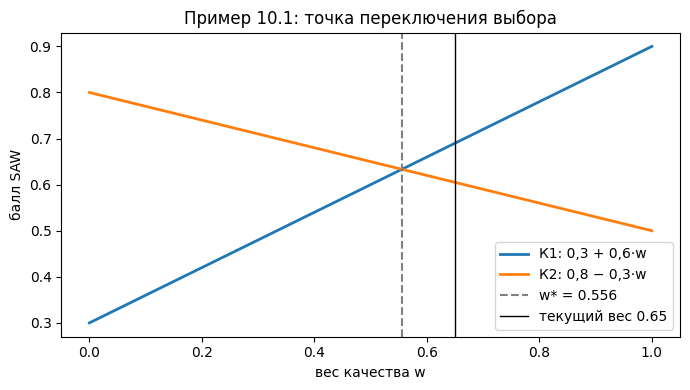

In [17]:
# =============================================================================
# ПРИМЕР 10.1 В КОДЕ: критический вес и запас устойчивости
# =============================================================================
q1, c1 = 0.9, 0.3        # курс К1: качество, удобство (уже нормализованы)
q2, c2 = 0.5, 0.8        # курс К2

def F1(w): return q1 * w + c1 * (1 - w)     # баллы SAW как функции веса качества w
def F2(w): return q2 * w + c2 * (1 - w)

w_now = 0.65
print(f"При w = {w_now}: F1 = {F1(w_now):.3f}, F2 = {F2(w_now):.3f}")

# Критический вес — корень уравнения F1(w) = F2(w). Обе функции линейны:
# (q1 − c1)·w + c1 = (q2 − c2)·w + c2  ⇒  w* = (c2 − c1) / ((q1 − c1) − (q2 − c2)).
w_star = (c2 - c1) / ((q1 - c1) - (q2 - c2))
check("критический вес w*", w_star, 0.556)
check("запас устойчивости", w_now - w_star, 0.094)

# График: две прямые пересекаются в точке w*.
w = np.linspace(0, 1, 101)               # 101 точка от 0 до 1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w, F1(w), lw=2, label="К1: 0,3 + 0,6·w")
ax.plot(w, F2(w), lw=2, label="К2: 0,8 − 0,3·w")
ax.axvline(w_star, color="grey", ls="--", label=f"w* = {w_star:.3f}")
ax.axvline(w_now, color="black", lw=1, label=f"текущий вес {w_now}")
ax.set_xlabel("вес качества w"); ax.set_ylabel("балл SAW")
ax.set_title("Пример 10.1: точка переключения выбора")
ax.legend(); plt.tight_layout(); plt.show()

---
# Что дальше

Все примеры проверены кодом. Теперь вернитесь к **основному ноутбуку** и посмотрите, как
те же функции работают в задаче путешественника, где матрица решений своя в каждой из
243 ситуаций.

### Упражнения для самостоятельной работы

1. **§2.** Добавьте шестую квартиру К6 с ценой 38, площадью 30 и дорогой 60. Изменится ли
   множество Парето? Изменится ли нормализация min–max столбца «Цена» у остальных квартир?
2. **§3.** Поднимите вес цены смартфонов с $0{,}35$ до $0{,}40$, уменьшив остальные веса
   пропорционально (формула 10.1). Кто победит по SAW? По WPM?
3. **§4.** Измените одно суждение в примере 4.1 так, чтобы $CR$ превысил $0{,}10$. Какое
   суждение для этого приходится менять сильнее всего?
4. **§6.** Найдите, при каком $c$ выпускнику из примера 6.1 станет всё равно, выбрать оклад
   или лотерею.
5. **§7.** Найдите точное значение $\nu$, при котором лидер в примере 7.1 меняется с М1 на М4.
6. **§8.** Подберите пороги ELECTRE I, при которых неперевзойдённым остаётся только З1.